<a href="https://colab.research.google.com/github/m-rafiul-islam/uiw-ds/blob/main/SAN_Diabetics_data_analysis_April20_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Copy the repository

In [9]:
# Clone the repository
!git clone https://github.com/m-rafiul-islam/uiw-ds.git

# Move into the directory to see the files
%cd uiw-ds/
!ls

Cloning into 'uiw-ds'...
remote: Enumerating objects: 64, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 64 (delta 26), reused 3 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (64/64), 20.26 MiB | 9.83 MiB/s, done.
Resolving deltas: 100% (26/26), done.
/content/uiw-ds/uiw-ds
 911.csv
 april25_waffle_word_sea_practice.ipynb
 april25_waffle_word_sea_solution.ipynb
'Copy of WM_SAT_Emp_Population_Output_UIW_20221003 (003).xlsx'
 data
 Data_2365_Sp25_Final_Project.ipynb
 DataScienceClassNoteSP24.ipynb
 diabetic_data_short_status4.csv
'Ecommerce Purchases'
 IntroDataScience_ClassNote_Spring25.ipynb
 math_datascience_activity.ipynb
 Math_DataScience_activity.ipynb
 README.md
 Salaries.csv
 SAN_Diabetics_data_analysis_April20_2026.ipynb
 Teaching_april25.pptx
 tips.csv
 USA_Housing.csv
 webscraping_mathjobs.ipynb
 wordclouds.txt


# Dataset Description
**General Columns (Common across multiple sheets)**
- **anon_id**: An anonymized identifier for each individual.
- **member_gender**: The gender of the individual.
- **member_age**: The age of the individual.
- **member_race**: The racial background of the individual.
- **Member_Ethnicity**: The ethnicity of the individual, noted as Hispanic/Latino or not.
- **market**: The geographic or market area associated with the individual.

### Specific Columns by Sheet

#### Diabetic_Pop
- **earliest_diabetes_dx**: Date of the earliest diagnosis of diabetes for the individual.

#### Fracture_pop
- **latest_frac_dx**: Date of the latest fracture diagnosis.
- **frac_dx**: Code or identifier for the fracture diagnosis.
- **frac_descr**: Description of the fracture.

#### Smoking_pop
- **most_recent_smoking_dx**: Most recent diagnosis related to smoking.

#### ETOH_pop
- **most_recent_Etoh_dx**: Most recent diagnosis related to alcohol use (Ethanol).

#### Lab Result Related Sheets (Gluc_lab_pop, A1c_lab_pop, Vit_D_Pop, Alk_Phos_pop, testost_pop, calcium_pop, glom_filt_pop)
- **Lab_Result_Date**: Date when the lab result was recorded.
- **Lab_Result_Name**: Name of the lab test.
- **[Specific lab value]**: Value of the specific lab test (e.g., Glucose_value, A1C_value, Vit_D_val, etc.).
- **[Specific lab measure]**: Measurement units or details for the specific lab test (e.g., Glucose_Measure, A1C_Measure, etc.).

#### Insulin_pop, Statin_pop, Glucocorticoid_pop
- **on_insulins**, **on_Statins**, **on_Glucocorticoids**: Indicators (likely boolean or date) showing whether the individual is on insulin, statins, or glucocorticoids respectively.

#### DEXA_pop
- **DEXA_Dt**: Date of the DEXA scan, a test used to measure bone density.
- **prim_dx**: Primary diagnosis code.
- **prim_dx_desc**: Description of the primary diagnosis.


# Fracture Analysis

## Filtering Patient Data for Specific Fracture Diagnosis Codes

In [8]:
import pandas as pd
# Load the Excel file
file_path = 'Copy of WM_SAT_Emp_Population_Output_UIW_20221003 (003).xlsx'
fracture_pop_df = pd.read_excel(file_path, sheet_name='Fracture_pop')
fracture_pop_df

,anon_id,latest_frac_dx,frac_dx,frac_descr
0,5F5063CE-686D-4A92-B0B8-5B2996221F38,2012-01-06,805.9,Open fracture of unspecified part of vertebral...
1,99123EA6-F708-41F8-BB9C-9F8458AC447C,2012-01-10,805.4,Closed fracture of lumbar vertebra without men...
2,4274D0F0-BAC3-44A8-9697-90E938CB4FDC,2012-01-13,820.8,Closed fracture of unspecified part of neck of...
3,21CE6E8E-787E-4091-95D4-3DD6C17751DD,2012-01-19,821.10,Open fracture of unspecified part of femur
4,127D5E0A-B489-46A7-BA35-45313899C339,2012-01-30,733.13,Pathologic fracture of vertebrae
...,...,...,...,...
1616,60AA80A4-44FD-4ABC-93ED-84BDB0F7BB01,2020-12-31,S52.502D,Unspecified fracture of the lower end of left ...
1617,D71708B6-C78C-422F-B1A1-1AA453E1E094,2020-12-31,S72.001A,Fracture of unspecified part of neck of right ...
1618,0D15AB20-57AC-4F4D-A54A-20587B0ABE3D,2020-12-31,M81.8,Other osteoporosis without current pathologica...
1619,88838264-0E86-4270-B25E-BDE1FAB8EEB5,2020-12-31,S92.011D,"Displaced fracture of body of right calcaneus,..."


In [ ]:
# Update the regex patterns to correctly interpret '*' as any sequence of alphanumeric characters
femur_patterns = [
    r'S72\.001[AB]', r'S72\.002[AB]', r'S72\.009[AB]',
    r'S72\.01.*[AB]', r'S72\.02.*[AB]', r'S72\.03.*[AB]', r'S72\.04.*[AB]',
    r'S72\.05.*[AB]', r'S72\.06.*[AB]', r'S72\.09.*[AB]', r'S72\.10.*[AB]',
    r'S72\.11.*[AB]', r'S72\.12.*[AB]', r'S72\.13.*[AB]', r'S72\.14.*[AB]',
    r'S72\.40.*[AB]', r'S72\.41.*[AB]', r'S72\.42.*[AB]', r'S72\.43.*[AB]',
    r'S72\.44.*[AB]', r'S72\.45.*[AB]', r'S72\.46.*[AB]', r'S72\.47.*[AB]',
    r'S72\.49.*[AB]', r'S72\.8X.*[AB]', r'S72\.9X[AB]'
]

humerus_patterns = [
    r'S42\.201A', r'S42\.202A', r'S42\.203A', r'S42\.211A', r'S42\.212A',
    r'S42\.221A', r'S42\.222A', r'S42\.30.*[AB]', r'S42\.31.*[AB]',
    r'S42\.32.*[AB]', r'S42\.33.*[AB]', r'S42\.34.*[AB]', r'S42\.35.*[AB]',
    r'S42\.36.*[AB]', r'S42\.37.*[AB]', r'S42\.38.*[AB]', r'S42\.39.*[AB]'
]

distal_radius_ulna_patterns = [
    r'S52\.5.*[ABC]', r'S52\.6.*[ABC]', r'M81\.0'
]

# Combine all patterns
all_patterns = femur_patterns + humerus_patterns + distal_radius_ulna_patterns
combined_pattern = r'|'.join(all_patterns)

# Filter the data based on the combined regex pattern
filtered_fracture_data = fracture_pop_df[fracture_pop_df['frac_dx'].str.contains(combined_pattern, regex=True, na=False)]
filtered_fracture_data

,anon_id,latest_frac_dx,frac_dx,frac_descr
181,92BDF039-041E-4808-AD08-118A61F394BA,2015-11-09,S72.411A,Displaced unspecified condyle fracture of lowe...
184,E38060D7-E831-4B76-A6B2-86A2D09C7105,2015-11-14,S72.002A,Fracture of unspecified part of neck of left f...
186,86B51CD9-EB28-4DF6-966F-6B1727D6E0BE,2015-11-29,S72.001A,Fracture of unspecified part of neck of right ...
187,8F51C752-1ED3-4501-B6EA-9236DA93A0EF,2015-12-04,S72.002A,Fracture of unspecified part of neck of left f...
188,269448BC-82EC-4D40-AF5B-1C0E5E04D172,2015-12-05,S72.115A,Nondisplaced fracture of greater trochanter of...
...,...,...,...,...
1605,F4F0D320-C32C-4109-9580-31CC262A2BAC,2020-12-28,M81.0,Age-related osteoporosis without current patho...
1608,2C191914-972E-47A0-8F6A-471FF0A2CD1E,2020-12-29,S72.144A,Nondisplaced intertrochanteric fracture of rig...
1609,8525D997-405B-445D-A4F8-39609B5D8EDA,2020-12-30,M81.0,Age-related osteoporosis without current patho...
1617,D71708B6-C78C-422F-B1A1-1AA453E1E094,2020-12-31,S72.001A,Fracture of unspecified part of neck of right ...


Before applying the specified filters, the dataset contained comprehensive fracture data for **1,621 unique patients**, encompassing a wide range of diagnosis codes. Not all these codes were relevant to our focused analysis.

**Filter Summary:**
The filters were applied to retain only specific fracture diagnosis codes relevant to our study. After this filtration, the dataset now includes records for **335 unique patients**. Here is a detailed breakdown:

- **Most Frequent Fracture Diagnosis Codes**:
  - `M81.0` (Osteoporosis without current pathological fracture) is the most frequently occurring diagnosis with 217 instances.
  - `S72.002A` (Fracture of unspecified part of neck of left femur, initial encounter for closed fracture) appears 23 times.
  - `S72.001A` (Fracture of unspecified part of neck of right femur, initial encounter for closed fracture) is noted 14 times.
  - Other codes such as `S72.141A`, `S72.142A`, and `S72.009A` appear less frequently but still significantly across the dataset.

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # Assuming 'filtered_fracture_data' is your DataFrame with the filtered fracture data
# # Convert the 'latest_frac_dx' column to datetime format
# filtered_fracture_data['latest_frac_dx'] = pd.to_datetime(filtered_fracture_data['latest_frac_dx'])

# # Group the data by month and count occurrences
# monthly_fractures = filtered_fracture_data.resample('M', on='latest_frac_dx').size()

# # Plot the time series of fractures
# plt.figure(figsize=(14, 4))
# plt.plot(monthly_fractures.index, monthly_fractures, marker='o', linestyle='-')
# plt.title('Monthly Fracture Trends')
# plt.xlabel('Month')
# plt.ylabel('Number of Fractures')
# plt.grid(True)

# The plot above shows the monthly trends of fractures based on the latest diagnosis dates in your filtered dataset.

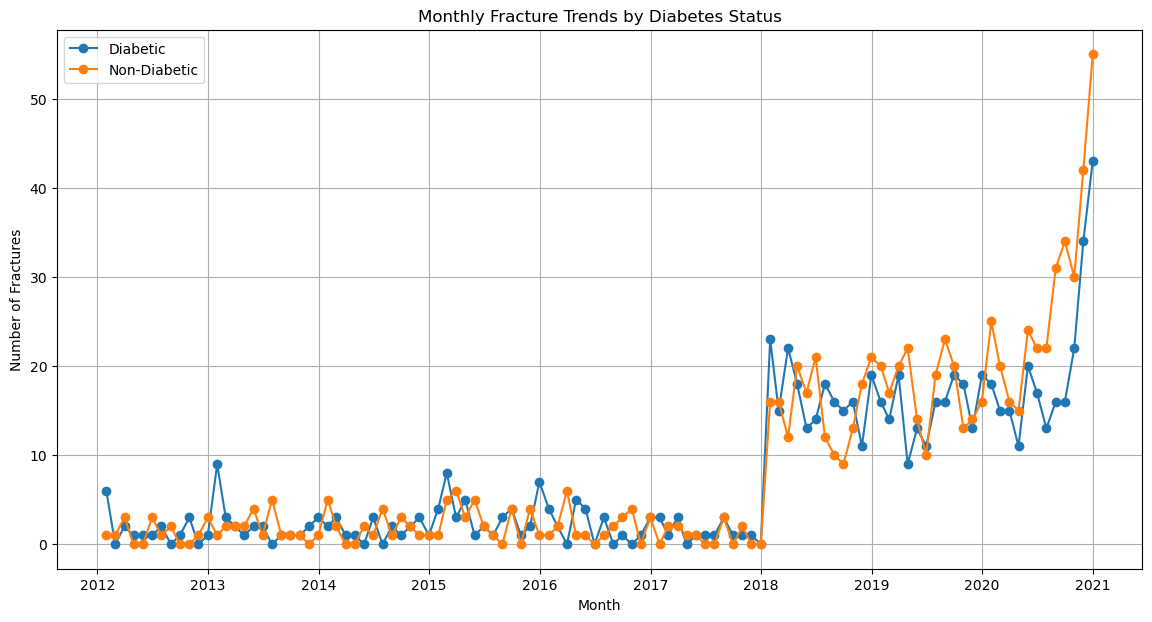

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
file_path = 'Copy of WM_SAT_Emp_Population_Output_UIW_20221003 (003).xlsx'
fracture_data = pd.read_excel(file_path, sheet_name='Fracture_pop')
diabetics_data = pd.read_excel(file_path, sheet_name='Diabetic_Pop')

# Merge the fracture data with diabetic status
fracture_with_diabetes_status = pd.merge(fracture_data, diabetics_data, on='anon_id', how='left')
fracture_with_diabetes_status['is_diabetic'] = fracture_with_diabetes_status['earliest_diabetes_dx'].notna().astype(int)

# Convert 'latest_frac_dx' to datetime format and set it as the index
fracture_with_diabetes_status['latest_frac_dx'] = pd.to_datetime(fracture_with_diabetes_status['latest_frac_dx'])

# Group data by month and diabetic status and count occurrences
monthly_fractures_by_diabetes = fracture_with_diabetes_status.groupby(['is_diabetic']).resample('M', on='latest_frac_dx').size().unstack(0)

# Separate the data for diabetic and non-diabetic groups
diabetic_series = monthly_fractures_by_diabetes.xs(1, level='is_diabetic').reindex(monthly_fractures_by_diabetes.index.levels[0], fill_value=0)
non_diabetic_series = monthly_fractures_by_diabetes.xs(0, level='is_diabetic').reindex(monthly_fractures_by_diabetes.index.levels[0], fill_value=0)

# Plot the time series for diabetic vs non-diabetic patients
plt.figure(figsize=(14, 7))
plt.plot(diabetic_series.index, diabetic_series, marker='o', linestyle='-', label='Diabetic')
plt.plot(non_diabetic_series.index, non_diabetic_series, marker='o', linestyle='-', label='Non-Diabetic')
plt.title('Monthly Fracture Trends by Diabetes Status')
plt.xlabel('Month')
plt.ylabel('Number of Fractures')
plt.legend()
plt.grid(True)
plt.show()


The plot now displays the monthly fracture trends, comparing diabetic and non-diabetic patients. Each group's data has been aligned across all months, with missing months filled with zeros, ensuring a consistent and clear visualization.

Since the numbers of diabetic and non-diabetic patients aren't equal, comparing their absolute numbers might not provide a clear insight into the relative trends or risks. To address this, we can normalize the data relative to the total number of patients in each group. This approach will allow us to compare the monthly fracture rates per capita within each group, providing a more balanced and meaningful comparison.

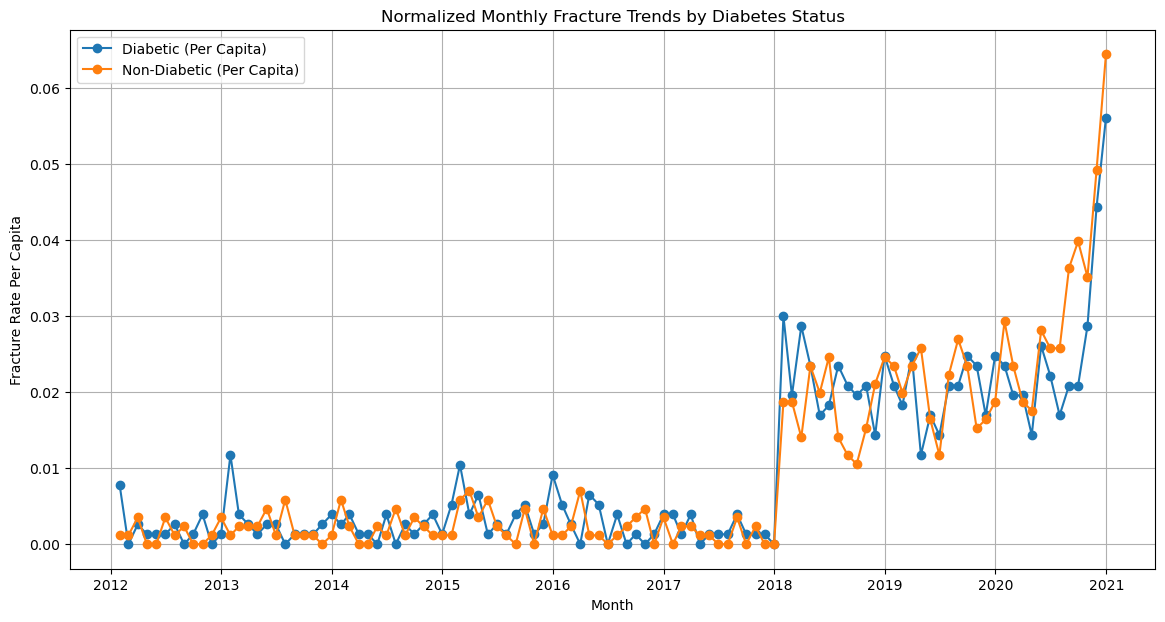

In [ ]:
# Calculate the total number of diabetic and non-diabetic patients
total_diabetic_patients = (fracture_with_diabetes_status['is_diabetic'] == 1).sum()
total_non_diabetic_patients = (fracture_with_diabetes_status['is_diabetic'] == 0).sum()

# Normalize the data by the total number of patients in each group to get per capita fracture rates
normalized_diabetic_series = diabetic_series / total_diabetic_patients
normalized_non_diabetic_series = non_diabetic_series / total_non_diabetic_patients

# Plot the normalized time series for diabetic vs non-diabetic patients
plt.figure(figsize=(14, 7))
plt.plot(normalized_diabetic_series.index, normalized_diabetic_series, marker='o', linestyle='-', label='Diabetic (Per Capita)')
plt.plot(normalized_non_diabetic_series.index, normalized_non_diabetic_series, marker='o', linestyle='-', label='Non-Diabetic (Per Capita)')
plt.title('Normalized Monthly Fracture Trends by Diabetes Status')
plt.xlabel('Month')
plt.ylabel('Fracture Rate Per Capita')
plt.legend()
plt.grid(True)
plt.show()


The plot now displays the normalized monthly fracture trends per capita for diabetic versus non-diabetic patients. The normalized plot suggests that diabetic patients may experience fewer fractures per capita compared to non-diabetic patients. This observation could be attributed to the more frequent healthcare interactions of diabetic individuals, which potentially enables better management of fracture risk factors. This counterintuitive finding highlights the importance of continuous healthcare engagement in managing and mitigating health risks.

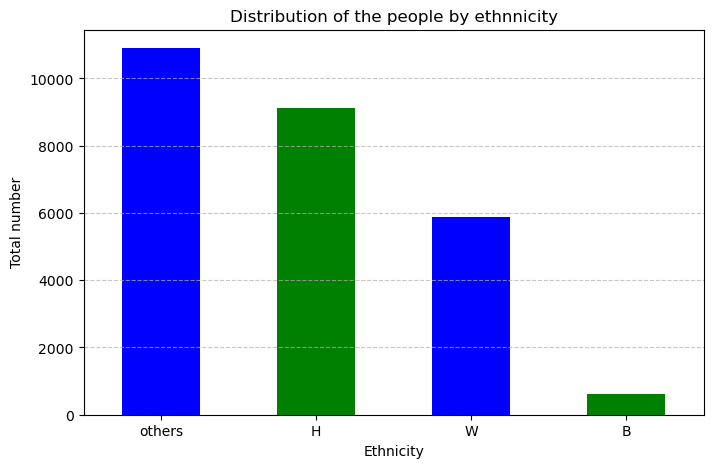

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the updated CSV file containing the assigned ethnicity
updated_target_population = pd.read_csv('target_population_df_assigned_ethnicity.csv')
# Load the "Diabetics_prop" and "Fracture_pop" sheets from the Excel file
diabetics_data = pd.read_excel(file_path, sheet_name='Diabetic_Pop')
fracture_data = pd.read_excel(file_path, sheet_name='Fracture_pop')

# Prepare data for plotting
ethnicity_counts = updated_target_population['Assigned_Ethnicity'].value_counts()

# Plotting the ethnicity comparison chart
plt.figure(figsize=(8, 5))
ethnicity_counts.plot(kind='bar', color=['blue', 'green'])
plt.title('Distribution of the people by ethnnicity')
plt.xlabel('Ethnicity')
plt.ylabel('Total number')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the datasets
updated_target_population = pd.read_csv('target_population_df_assigned_ethnicity.csv')
diabetics_data = pd.read_excel(file_path, sheet_name='Diabetic_Pop')
fracture_data = pd.read_excel(file_path, sheet_name='Fracture_pop')

# Merge the datasets
merged_data = pd.merge(diabetics_data, fracture_data, on='anon_id', how='inner')
merged_data = pd.merge(merged_data, updated_target_population[['anon_id', 'Assigned_Ethnicity']], on='anon_id', how='left')
merged_data

,anon_id,earliest_diabetes_dx,latest_frac_dx,frac_dx,frac_descr,Assigned_Ethnicity
0,4233060B-F88C-433A-B66B-B50A18246A01,2012-08-23,2019-10-18,M80.00XS,Age-related osteoporosis with current patholog...,H
1,99B49830-6208-44A6-96EB-6849BCF4E5AF,2015-03-30,2020-05-08,S92.414D,Nondisplaced fracture of proximal phalanx of r...,W
2,5A049389-7660-474A-8366-5514AC4C00EE,2012-01-04,2018-04-30,S12.9XXS,"Fracture of neck, unspecified, sequela",others
3,DFB29A06-F54B-4BB8-B3D7-9141D2B32C71,2012-02-14,2014-11-07,820.21,Closed fracture of intertrochanteric section o...,H
4,1A5B501B-265C-49BE-9EB6-A239CA2AA2E6,2015-12-26,2017-01-03,S32.010A,Wedge compression fracture of first lumbar ver...,H
...,...,...,...,...,...,...
762,08CB8633-2228-4DD8-96D6-73B1ACEF7BC8,2019-01-18,2020-11-12,S22.42XA,"Multiple fractures of ribs, left side, initial...",W
763,FA79EFEE-281E-4CB9-ADA2-E50374AED514,2016-11-07,2019-06-12,S62.617A,Displaced fracture of proximal phalanx of left...,others
764,3FC2EF82-38E1-4F0D-B7B6-C2629B9B9E3E,2015-02-13,2020-11-14,S22.31XA,"Fracture of one rib, right side, initial encou...",H
765,1FAB0CE1-E999-4D68-BC65-4A997D6BE099,2016-07-01,2018-10-29,S22.21XA,"Fracture of manubrium, initial encounter for c...",others


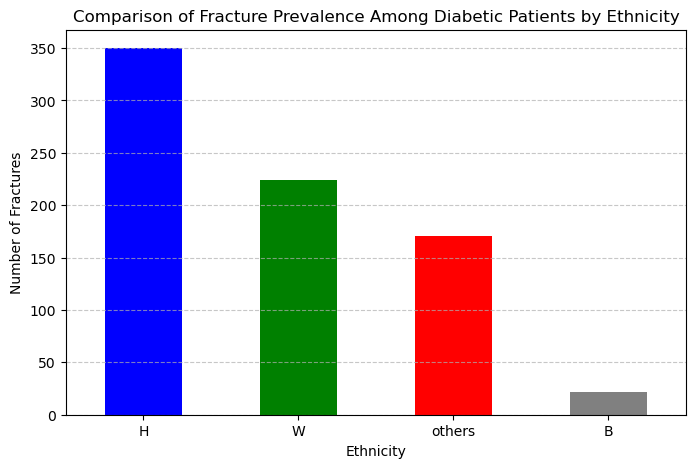

In [ ]:

# Filter for diabetic patients (assuming all in diabetics_data are diabetic)
# and count fractures per ethnicity
fracture_counts = merged_data['Assigned_Ethnicity'].value_counts()

# Plotting the fracture prevalence by ethnicity
plt.figure(figsize=(8, 5))
fracture_counts.plot(kind='bar', color=['blue', 'green', 'red', 'gray'])
plt.title('Comparison of Fracture Prevalence Among Diabetic Patients by Ethnicity')
plt.xlabel('Ethnicity')
plt.ylabel('Number of Fractures')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


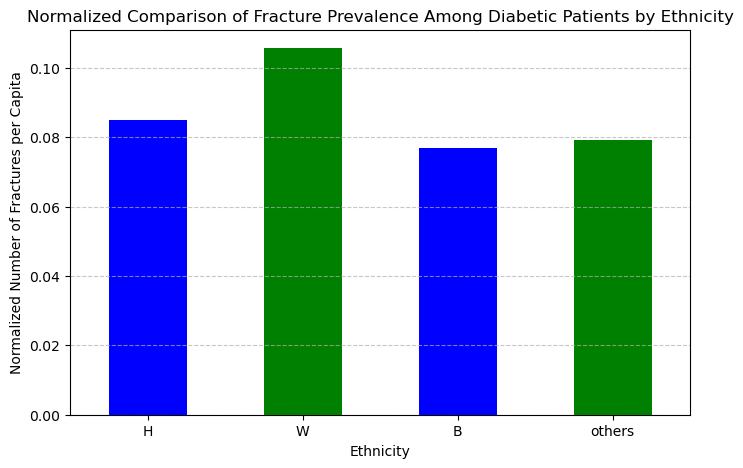

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the datasets
updated_target_population = pd.read_csv('target_population_df_assigned_ethnicity.csv')
diabetics_data = pd.read_excel(file_path, sheet_name='Diabetic_Pop')
fracture_data = pd.read_excel(file_path, sheet_name='Fracture_pop')

# Merge the datasets
merged_data = pd.merge(diabetics_data, fracture_data, on='anon_id', how='inner')
merged_data = pd.merge(merged_data, updated_target_population[['anon_id', 'Assigned_Ethnicity']], on='anon_id', how='left')

# Filter the data for diabetic patients (assuming diabetes data indicates diabetes presence)
ethnic_diabetic_data = merged_data[merged_data['anon_id'].isin(diabetics_data['anon_id'])]

# Count the fractures per ethnicity among diabetic patients
fracture_counts_by_ethnicity = ethnic_diabetic_data['Assigned_Ethnicity'].value_counts()

# Calculate the total number of diabetic patients per ethnic group from the updated target population
ethnic_diabetic_counts = updated_target_population[updated_target_population['anon_id'].isin(diabetics_data['anon_id'])]['Assigned_Ethnicity'].value_counts()

# Normalize the fracture counts by the number of diabetic patients in each ethnic group
normalized_fracture_counts = fracture_counts_by_ethnicity / ethnic_diabetic_counts

# Create the plot
plt.figure(figsize=(8, 5))
normalized_fracture_counts[['H', 'W','B','others']].plot(kind='bar', color=['blue', 'green'])  # Assuming only 'H' and 'W' are needed
plt.title('Normalized Comparison of Fracture Prevalence Among Diabetic Patients by Ethnicity')
plt.xlabel('Ethnicity')
plt.ylabel('Normalized Number of Fractures per Capita')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

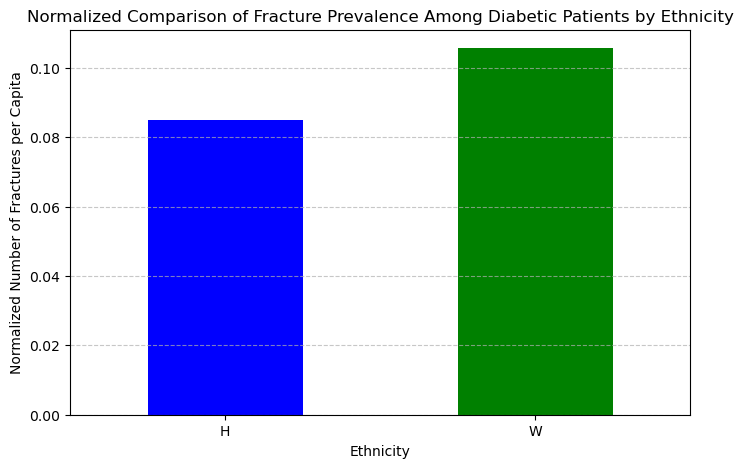

In [ ]:
# Create the plot
plt.figure(figsize=(8, 5))
normalized_fracture_counts[['H', 'W']].plot(kind='bar', color=['blue', 'green'])  # Assuming only 'H' and 'W' are needed
plt.title('Normalized Comparison of Fracture Prevalence Among Diabetic Patients by Ethnicity')
plt.xlabel('Ethnicity')
plt.ylabel('Normalized Number of Fractures per Capita')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The bar chart displays the normalized comparison of fracture prevalence among diabetic patients by ethnicity, specifically comparing Hispanic (H) and non-Hispanic White (W) groups. Here are the key takeaways from the plot:

- **Fracture Rates**: Both ethnic groups exhibit noticeable differences in fracture rates when adjusted for the size of the diabetic population in each group. Non-Hispanic White patients show a higher normalized fracture rate compared to Hispanic patients.
- **Interpretation**: The higher rate among non-Hispanic Whites suggests that, per capita, these individuals might be more prone to fractures compared to their Hispanic counterparts among the diabetic population.

This analysis provides valuable insights into how diabetes and ethnicity may intersect to influence fracture risks, emphasizing the importance of considering ethnic backgrounds in medical research and healthcare strategies.

# Data cleaning for member race and member ethnicity

In [ ]:
import pandas as pd
# Load the Excel file
file_path = 'Copy of WM_SAT_Emp_Population_Output_UIW_20221003 (003).xlsx'
# Load the sheets
target_population_df = pd.read_excel(file_path, sheet_name='Target_population')
target_population_df

,anon_id,member_gender,member_age,member_race,Member_Ethnicity,market
0,F7D31775-C766-437C-8F20-5873168374F3,M,75,Hispanic,Not Hispanic or Latino,San Antonio
1,5E33C22D-198D-4771-A456-A711FAB53E15,M,81,NaN,NaN,San Antonio
2,5F430FF2-346F-434A-8A45-04D5795F0EEC,M,79,Hispanic,Hispanic or Latino,San Antonio
3,C5984BA6-37B2-4315-A52B-3C28E8DD34CA,M,76,White,Not Hispanic or Latino,San Antonio
4,4CEB8191-1B88-4FDB-A0BC-05AD96A125BA,M,86,NaN,NaN,San Antonio
...,...,...,...,...,...,...
26505,27CAD9DA-FED2-4F7D-B265-2D6E52209DE4,M,61,Hispanic,Hispanic or Latino,San Antonio
26506,39DC8F1F-32B9-41BC-885E-6E29F1C79BB8,M,78,Hispanic,Hispanic or Latino,San Antonio
26507,2B3165D7-5305-469D-8DD2-2257D94CB16F,M,66,Declined to Specify,Mexican,San Antonio
26508,99D097C8-3A95-4BBF-9CC2-8793895710B6,M,68,NaN,NaN,San Antonio


In [ ]:
target_population_df['member_race'].value_counts()

White                                        7727
Hispanic                                     7423
Other Race                                    829
Unreported/Refused to Report                  791
Declined to Specify                           688
Black or African American                     598
Asian                                         124
African American                               21
American Indian or Alaska Native               17
Native Hawaiian or Other Pacific Islander      12
Declined To Specify                             9
Mexican American Indian                         8
English                                         5
Other Pacific Islander                          3
Black                                           2
Spanish American Indian                         2
European                                        1
American Indian                                 1
white                                           1
White Earth                                     1


In [ ]:
target_population_df['member_race'] = target_population_df['member_race'].replace(['white','Caucasian','English','European'],'White').replace('African American','Black or African American').replace('Black','Black or African American')
target_population_df['member_race'] = target_population_df['member_race'].replace(['Unreported/Refused to Report','Declined to Specify','Declined To Specify'],'Refused to Report')
target_population_df['member_race'].value_counts()

White                                        7735
Hispanic                                     7423
Refused to Report                            1488
Other Race                                    829
Black or African American                     621
Asian                                         124
American Indian or Alaska Native               17
Native Hawaiian or Other Pacific Islander      12
Mexican American Indian                         8
Other Pacific Islander                          3
Spanish American Indian                         2
American Indian                                 1
White Earth                                     1
Vietnamese                                      1
Name: member_race, dtype: int64

In [ ]:
target_population_df['Member_Ethnicity'] = target_population_df['Member_Ethnicity'].replace('Declined to Specify','Refused to Report').replace('Mexican American','Mexican')
target_population_df['Member_Ethnicity'].value_counts()

Hispanic or Latino        9580
Not Hispanic or Latino    6832
Refused to Report         1768
Mexican                     17
Latin American               1
Puerto Rican                 1
Central American             1
Name: Member_Ethnicity, dtype: int64

Use these rules:

1 White + Hispanic or Latino = Hispanic

2 White + not/reported/null/no answer = White

3 Black (AA) + Hispanic = Black

4 Black (AA) + not/reported/null/no answer = Black


Columns D and E in the tab “Target_population” contain all the information for establishing the three demographic groups: Non-Hispanic White (W), Black (B), and Hispanic (H)

Please use the following rules


Col D               Col E          Assigned Ethnicity for Study

W            +             H            =             H

W            +             **           =             W

B             +             H            =             B

B             +             **           =             B

In [ ]:
def assign_ethnicity(row):
    # Handle possible non-string values
    race = str(row['member_race']).strip().lower() if pd.notnull(row['member_race']) else ''
    ethnicity = str(row['Member_Ethnicity']).strip().lower() if pd.notnull(row['Member_Ethnicity']) else ''

    if race == 'white' and ethnicity == 'hispanic or latino':
        return 'H'
    elif race == 'hispanic' and ethnicity == 'hispanic or latino':
        return 'H'
    elif race == 'white':
        return 'W'
    elif race in ['black', 'african american', 'black or african american']:
        return 'B'
    else:
        return 'others'  # or 'Unknown' depending on how you want to handle these cases

# Apply the function to create the Assigned_Ethnicity column
target_population_df['Assigned_Ethnicity'] = target_population_df.apply(assign_ethnicity, axis=1)
target_population_df.to_csv('target_population_df_assigned_ethnicity.csv')
target_population_df
# Check the result
# print(target_population_df[['member_race', 'Member_Ethnicity', 'Assigned_Ethnicity']].head(20))


,anon_id,member_gender,member_age,member_race,Member_Ethnicity,market,Assigned_Ethnicity
0,F7D31775-C766-437C-8F20-5873168374F3,M,75,Hispanic,Not Hispanic or Latino,San Antonio,others
1,5E33C22D-198D-4771-A456-A711FAB53E15,M,81,NaN,NaN,San Antonio,others
2,5F430FF2-346F-434A-8A45-04D5795F0EEC,M,79,Hispanic,Hispanic or Latino,San Antonio,H
3,C5984BA6-37B2-4315-A52B-3C28E8DD34CA,M,76,White,Not Hispanic or Latino,San Antonio,W
4,4CEB8191-1B88-4FDB-A0BC-05AD96A125BA,M,86,NaN,NaN,San Antonio,others
...,...,...,...,...,...,...,...
26505,27CAD9DA-FED2-4F7D-B265-2D6E52209DE4,M,61,Hispanic,Hispanic or Latino,San Antonio,H
26506,39DC8F1F-32B9-41BC-885E-6E29F1C79BB8,M,78,Hispanic,Hispanic or Latino,San Antonio,H
26507,2B3165D7-5305-469D-8DD2-2257D94CB16F,M,66,Refused to Report,Mexican,San Antonio,others
26508,99D097C8-3A95-4BBF-9CC2-8793895710B6,M,68,NaN,NaN,San Antonio,others


In [ ]:
target_population_df_White = target_population_df[target_population_df['Assigned_Ethnicity']=='W']
target_population_df_Hispanic = target_population_df[target_population_df['Assigned_Ethnicity']=='H']
target_population_df_Black = target_population_df[target_population_df['Assigned_Ethnicity']=='B']
target_population_df_Others = target_population_df[target_population_df['Assigned_Ethnicity']=='others']
print(f'There are {len(target_population_df_White)} White people, '
      f'{len(target_population_df_Hispanic)} Hispanic people, '
      f'{len(target_population_df_Black)} Black people, and '
      f'{len(target_population_df_Others)} people from other ethnic groups or information unavailable.')

There are 5867 White people, 9119 Hispanic people, 621 Black people, and 10903 people from other ethnic groups or information unavailable.


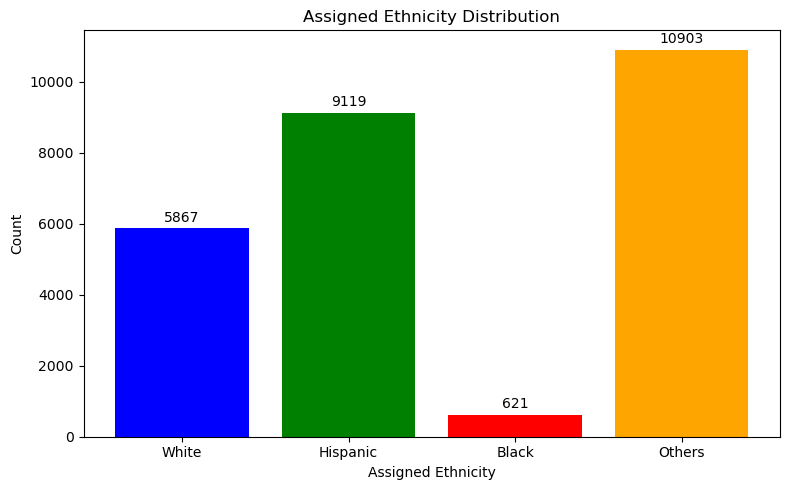

In [ ]:
import matplotlib.pyplot as plt
# Creating the labels and counts based on the filtered data
ethnicity_labels = ['White', 'Hispanic', 'Black', 'Others']
ethnicity_counts = [
    len(target_population_df_White),
    len(target_population_df_Hispanic),
    len(target_population_df_Black),
    len(target_population_df_Others)
]

# Plotting the bar graph
plt.figure(figsize=(8, 5))
bars = plt.bar(ethnicity_labels, ethnicity_counts, color=['blue', 'green', 'red', 'orange'])

# Adding number labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 100, int(yval), ha='center', va='bottom')

plt.title('Assigned Ethnicity Distribution')
plt.xlabel('Assigned Ethnicity')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()

# Display the plot
plt.show()

##  Age analysis

In [ ]:
target_population_df['member_age'].describe()

count    26510.000000
mean        72.258770
std          7.781948
min         60.000000
25%         66.000000
50%         71.000000
75%         78.000000
max         89.000000
Name: member_age, dtype: float64

In [ ]:
fracture_pop_df

,anon_id,latest_frac_dx,frac_dx,frac_descr
0,5F5063CE-686D-4A92-B0B8-5B2996221F38,2012-01-06,805.9,Open fracture of unspecified part of vertebral...
1,99123EA6-F708-41F8-BB9C-9F8458AC447C,2012-01-10,805.4,Closed fracture of lumbar vertebra without men...
2,4274D0F0-BAC3-44A8-9697-90E938CB4FDC,2012-01-13,820.8,Closed fracture of unspecified part of neck of...
3,21CE6E8E-787E-4091-95D4-3DD6C17751DD,2012-01-19,821.10,Open fracture of unspecified part of femur
4,127D5E0A-B489-46A7-BA35-45313899C339,2012-01-30,733.13,Pathologic fracture of vertebrae
...,...,...,...,...
1616,60AA80A4-44FD-4ABC-93ED-84BDB0F7BB01,2020-12-31,S52.502D,Unspecified fracture of the lower end of left ...
1617,D71708B6-C78C-422F-B1A1-1AA453E1E094,2020-12-31,S72.001A,Fracture of unspecified part of neck of right ...
1618,0D15AB20-57AC-4F4D-A54A-20587B0ABE3D,2020-12-31,M81.8,Other osteoporosis without current pathologica...
1619,88838264-0E86-4270-B25E-BDE1FAB8EEB5,2020-12-31,S92.011D,"Displaced fracture of body of right calcaneus,..."


In [ ]:
# Load the Excel file
file_path = 'Copy of WM_SAT_Emp_Population_Output_UIW_20221003 (003).xlsx'

# Load all sheets into a dictionary of DataFrames
excel_data = pd.read_excel(file_path, sheet_name=None)

# Display the sheet names to confirm data loading
print(excel_data.keys())

# Load specific sheets for further processing
target_population_df = excel_data['Target_population']
fracture_pop_df = excel_data['Fracture_pop']
a1c_lab_pop_df = excel_data['A1c_lab_pop']

# Convert the relevant dates to datetime format
fracture_pop_df['latest_frac_dx'] = pd.to_datetime(fracture_pop_df['latest_frac_dx'])
a1c_lab_pop_df['hba1c_date'] = pd.to_datetime(a1c_lab_pop_df['Lab_Result_Date'])

# Reference date when the dataset was created
reference_date = pd.to_datetime('2022-10-04')

# Calculate birth year based on age at the reference date
target_population_df['birth_year'] = reference_date.year - target_population_df['member_age']
# Merge the fracture and A1c data with the target population data based on patient ID
merged_fracture_df = pd.merge(fracture_pop_df, target_population_df, on='anon_id', how='left')

dict_keys(['Target_population', 'Diabetic_Pop', 'Fracture_pop', 'Smoking_pop', 'ETOH_pop', 'Gluc_lab_pop', 'A1c_lab_pop', 'Vit_D_Pop', 'Alk_Phos_pop', 'testost_pop', 'calcium_pop', 'glom_filt_pop', 'Insulin_pop', 'Statin_pop', 'Glucocorticoid_pop', 'DEXA_pop'])


0       60-69
1         NaN
2       70-79
3         NaN
4         NaN
        ...  
1616    70-79
1617    70-79
1618    70-79
1619    70-79
1620    70-79
Name: Age at Fracture, Length: 1621, dtype: category
Categories (4, object): ['60-69' < '70-79' < '80-89' < '90+']

In [ ]:
merged_fracture_df

,anon_id,latest_frac_dx,frac_dx,frac_descr,member_gender,member_age,member_race,Member_Ethnicity,market,birth_year,Age at Fracture
0,5F5063CE-686D-4A92-B0B8-5B2996221F38,2012-01-06,805.9,Open fracture of unspecified part of vertebral...,M,75,Hispanic,Hispanic or Latino,San Antonio,1947,65
1,99123EA6-F708-41F8-BB9C-9F8458AC447C,2012-01-10,805.4,Closed fracture of lumbar vertebra without men...,M,70,Hispanic,Hispanic or Latino,San Antonio,1952,60
2,4274D0F0-BAC3-44A8-9697-90E938CB4FDC,2012-01-13,820.8,Closed fracture of unspecified part of neck of...,M,83,NaN,NaN,San Antonio,1939,73
3,21CE6E8E-787E-4091-95D4-3DD6C17751DD,2012-01-19,821.10,Open fracture of unspecified part of femur,M,60,White,Hispanic or Latino,San Antonio,1962,50
4,127D5E0A-B489-46A7-BA35-45313899C339,2012-01-30,733.13,Pathologic fracture of vertebrae,M,62,NaN,NaN,San Antonio,1960,52
...,...,...,...,...,...,...,...,...,...,...,...
1616,60AA80A4-44FD-4ABC-93ED-84BDB0F7BB01,2020-12-31,S52.502D,Unspecified fracture of the lower end of left ...,M,81,Hispanic,Hispanic or Latino,San Antonio,1941,79
1617,D71708B6-C78C-422F-B1A1-1AA453E1E094,2020-12-31,S72.001A,Fracture of unspecified part of neck of right ...,M,72,Hispanic,Hispanic or Latino,San Antonio,1950,70
1618,0D15AB20-57AC-4F4D-A54A-20587B0ABE3D,2020-12-31,M81.8,Other osteoporosis without current pathologica...,M,76,Black or African American,Not Hispanic or Latino,San Antonio,1946,74
1619,88838264-0E86-4270-B25E-BDE1FAB8EEB5,2020-12-31,S92.011D,"Displaced fracture of body of right calcaneus,...",M,76,White,Hispanic or Latino,San Antonio,1946,74


In [ ]:
# Calculate the age at the time of the fracture
merged_fracture_df['Age at Fracture'] = merged_fracture_df['latest_frac_dx'].dt.year - merged_fracture_df['birth_year']
merged_fracture_df

,anon_id,latest_frac_dx,frac_dx,frac_descr,member_gender,member_age,member_race,Member_Ethnicity,market,birth_year,Age at Fracture
0,5F5063CE-686D-4A92-B0B8-5B2996221F38,2012-01-06,805.9,Open fracture of unspecified part of vertebral...,M,75,Hispanic,Hispanic or Latino,San Antonio,1947,65
1,99123EA6-F708-41F8-BB9C-9F8458AC447C,2012-01-10,805.4,Closed fracture of lumbar vertebra without men...,M,70,Hispanic,Hispanic or Latino,San Antonio,1952,60
2,4274D0F0-BAC3-44A8-9697-90E938CB4FDC,2012-01-13,820.8,Closed fracture of unspecified part of neck of...,M,83,NaN,NaN,San Antonio,1939,73
3,21CE6E8E-787E-4091-95D4-3DD6C17751DD,2012-01-19,821.10,Open fracture of unspecified part of femur,M,60,White,Hispanic or Latino,San Antonio,1962,50
4,127D5E0A-B489-46A7-BA35-45313899C339,2012-01-30,733.13,Pathologic fracture of vertebrae,M,62,NaN,NaN,San Antonio,1960,52
...,...,...,...,...,...,...,...,...,...,...,...
1616,60AA80A4-44FD-4ABC-93ED-84BDB0F7BB01,2020-12-31,S52.502D,Unspecified fracture of the lower end of left ...,M,81,Hispanic,Hispanic or Latino,San Antonio,1941,79
1617,D71708B6-C78C-422F-B1A1-1AA453E1E094,2020-12-31,S72.001A,Fracture of unspecified part of neck of right ...,M,72,Hispanic,Hispanic or Latino,San Antonio,1950,70
1618,0D15AB20-57AC-4F4D-A54A-20587B0ABE3D,2020-12-31,M81.8,Other osteoporosis without current pathologica...,M,76,Black or African American,Not Hispanic or Latino,San Antonio,1946,74
1619,88838264-0E86-4270-B25E-BDE1FAB8EEB5,2020-12-31,S92.011D,"Displaced fracture of body of right calcaneus,...",M,76,White,Hispanic or Latino,San Antonio,1946,74


In [ ]:
# Group by age categories for fractures
age_groups_fracture = pd.cut(merged_fracture_df['Age at Fracture'], bins=[60, 69, 79, 89, 99], labels=['60-69', '70-79', '80-89', '90+'])
age_groups_fracture

0       60-69
1         NaN
2       70-79
3         NaN
4         NaN
        ...  
1616    70-79
1617    70-79
1618    70-79
1619    70-79
1620    70-79
Name: Age at Fracture, Length: 1621, dtype: category
Categories (4, object): ['60-69' < '70-79' < '80-89' < '90+']

## Relationship between fracture and age --- relationship between fracture and A1c_Values


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure you are using the correct DataFrame and column name
# Example: Assuming 'A1c_Result' is the correct column for HbA1c values
merged_data = pd.merge(merged_fracture_df, a1c_lab_pop_df, on='anon_id', how='inner')
merged_data

,anon_id,latest_frac_dx,frac_dx,frac_descr,member_gender,member_age,member_race,Member_Ethnicity,market,birth_year,Age at Fracture,Lab_Result_Date,Lab_Result_Name,A1C_value,A1C_Measure,hba1c_date
0,5F5063CE-686D-4A92-B0B8-5B2996221F38,2012-01-06,805.9,Open fracture of unspecified part of vertebral...,M,75,Hispanic,Hispanic or Latino,San Antonio,1947,65,2011-05-23,HEMOGLOBIN A1C,6.6,%,2011-05-23
1,99123EA6-F708-41F8-BB9C-9F8458AC447C,2012-01-10,805.4,Closed fracture of lumbar vertebra without men...,M,70,Hispanic,Hispanic or Latino,San Antonio,1952,60,2018-05-16,Hemoglobin A1c,6.8,%,2018-05-16
2,4274D0F0-BAC3-44A8-9697-90E938CB4FDC,2012-01-13,820.8,Closed fracture of unspecified part of neck of...,M,83,NaN,NaN,San Antonio,1939,73,2011-12-12,Hemoglobin A1c,NaN,NaN,2011-12-12
3,21CE6E8E-787E-4091-95D4-3DD6C17751DD,2012-01-19,821.10,Open fracture of unspecified part of femur,M,60,White,Hispanic or Latino,San Antonio,1962,50,2011-06-15,HEMOGLOBIN A1C,6.0,%,2011-06-15
4,127D5E0A-B489-46A7-BA35-45313899C339,2012-01-30,733.13,Pathologic fracture of vertebrae,M,62,NaN,NaN,San Antonio,1960,52,2011-07-22,HEMOGLOBIN A1C,5.3,%,2011-07-22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1450,9DFAC932-5D29-49A7-BB72-309599D6AEDA,2020-12-30,S82.831D,Other fracture of upper and lower end of right...,M,73,White,Not Hispanic or Latino,San Antonio,1949,71,2012-10-26,HEMOGLOBIN A1C,5.6,%,2012-10-26
1451,D71708B6-C78C-422F-B1A1-1AA453E1E094,2020-12-31,S72.001A,Fracture of unspecified part of neck of right ...,M,72,Hispanic,Hispanic or Latino,San Antonio,1950,70,2014-08-07,HEMOGLOBIN A1C,6.1,%,2014-08-07
1452,0D15AB20-57AC-4F4D-A54A-20587B0ABE3D,2020-12-31,M81.8,Other osteoporosis without current pathologica...,M,76,Black or African American,Not Hispanic or Latino,San Antonio,1946,74,2012-08-17,Hemoglobin A1c,6.0,%,2012-08-17
1453,88838264-0E86-4270-B25E-BDE1FAB8EEB5,2020-12-31,S92.011D,"Displaced fracture of body of right calcaneus,...",M,76,White,Hispanic or Latino,San Antonio,1946,74,2019-02-12,Hemoglobin A1c,5.6,%,2019-02-12


In [ ]:
merged_data.to_csv('fracture_vs_A1C_value.csv')

In [ ]:
# Calculate correlation
correlation = merged_data[['Age at Fracture', 'A1C_value']].corr()  # Adjust 'A1c_Result' as found to be correct
correlation

In [ ]:
# Plotting the correlation
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation between Age at Fracture and HbA1c Levels')
plt.show()

In [ ]:
# Merge HbA1c data into the fracture data
full_merged_df = pd.merge(merged_fracture_df, a1c_lab_pop_df, on='anon_id', how='left')


In [ ]:
full_merged_df.columns

Index(['anon_id', 'latest_frac_dx', 'frac_dx', 'frac_descr', 'member_gender',
       'member_age', 'member_race', 'Member_Ethnicity', 'market', 'birth_year',
       'Age at Fracture', 'Lab_Result_Date', 'Lab_Result_Name', 'A1C_value',
       'A1C_Measure', 'hba1c_date'],
      dtype='object')

In [ ]:

# Calculate correlation between age at fracture and HbA1c levels
correlation = full_merged_df[['Age at Fracture', 'A1C_value']].corr()  # Replace 'HbA1c_level' with the correct column name

# Display correlation
print("Correlation between Age at Fracture and HbA1c Levels:")
print(correlation)


Correlation between Age at Fracture and HbA1c Levels:
                 Age at Fracture
Age at Fracture              1.0


## test

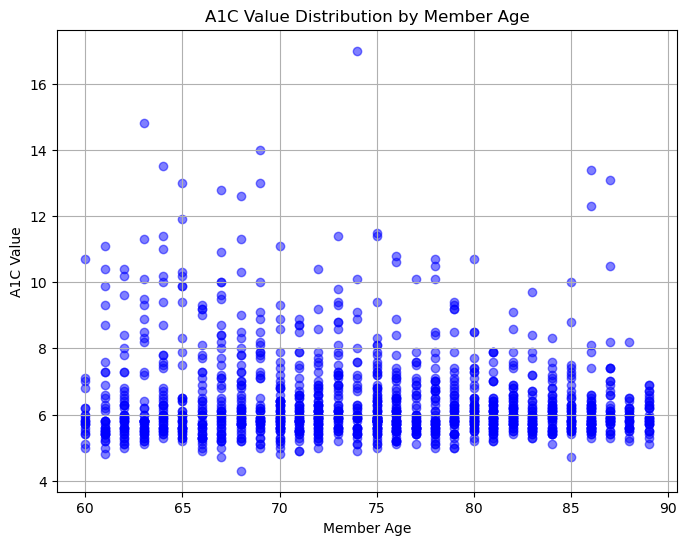

In [ ]:
# Plotting a scatter plot to show the distribution of A1C values by member_age
data = merged_data
plt.figure(figsize=(8, 6))
plt.scatter(data['member_age'], pd.to_numeric(data['A1C_value'], errors='coerce'), alpha=0.5, color='blue')
plt.title('A1C Value Distribution by Member Age')
plt.xlabel('Member Age')
plt.ylabel('A1C Value')
plt.grid(True)
plt.show()

Here is a scatter plot showing the distribution of A1C values by member age. Each point represents a person's A1C value and their corresponding age. The plot shows a general spread of A1C values across different age groups, with a concentration around the lower A1C values.

## HbA1c (measure of diabetes management)

In [ ]:
import pandas as pd

# Load the Excel file
file_path = 'Copy of WM_SAT_Emp_Population_Output_UIW_20221003 (003).xlsx'

# Load all sheets into a dictionary of DataFrames
excel_data = pd.read_excel(file_path, sheet_name=None)

# Load specific sheets for further processing
target_population_df = excel_data['Target_population']
fracture_pop_df = excel_data['Fracture_pop']
a1c_lab_pop_df = excel_data['A1c_lab_pop']

# Convert the relevant dates to datetime format
fracture_pop_df['latest_frac_dx'] = pd.to_datetime(fracture_pop_df['latest_frac_dx'])
a1c_lab_pop_df['Lab_Result_Date'] = pd.to_datetime(a1c_lab_pop_df['Lab_Result_Date'])

# Reference date when the dataset was created
reference_date = pd.to_datetime('2022-10-04')

# Calculate birth year based on age at the reference date
target_population_df['birth_year'] = reference_date.year - target_population_df['member_age']

# Merge the fracture and A1c data with the target population data based on patient ID
merged_fracture_df = pd.merge(fracture_pop_df, target_population_df, on='anon_id', how='left')
merged_a1c_df = pd.merge(a1c_lab_pop_df, target_population_df, on='anon_id', how='left')

# Calculate the age at the time of the fracture
merged_fracture_df['Age at Fracture'] = merged_fracture_df['latest_frac_dx'].dt.year - merged_fracture_df['birth_year']

# Convert 'A1C_value' to numeric, handling non-numeric entries
merged_a1c_df['A1C_value'] = pd.to_numeric(merged_a1c_df['A1C_value'], errors='coerce')

# Calculate overall statistics for A1C_value
overall_stats = merged_a1c_df['A1C_value'].agg(['mean', 'median', 'std'])

# Create age groups and calculate statistics for each group
merged_a1c_df['age_group'] = pd.cut(merged_a1c_df['member_age'], bins=[59, 69, 79, 89], labels=['60-69', '70-79', '80-89'], right=True)
age_group_stats = merged_a1c_df.groupby('age_group')['A1C_value'].agg(['mean', 'median', 'std'])

# Display the results
print("Overall Statistics for A1C values:")
print(overall_stats)
print("\nStatistics by Age Group:")
print(age_group_stats)


Overall Statistics for A1C values:
mean      6.458836
median    6.000000
std       1.350036
Name: A1C_value, dtype: float64

Statistics by Age Group:
               mean  median       std
age_group                            
60-69      6.591002     6.0  1.592236
70-79      6.449013     6.1  1.245310
80-89      6.249440     6.0  0.995002


In [ ]:
merged_fracture_df['Age at Fracture']

0       65
1       60
2       73
3       50
4       52
        ..
1616    79
1617    70
1618    74
1619    74
1620    78
Name: Age at Fracture, Length: 1621, dtype: int64

In [ ]:
# Calculate the age at the time of the HbA1c measurement
merged_a1c_df['Age at HbA1c'] = merged_a1c_df['hba1c_date'].dt.year - merged_a1c_df['birth_year']


In [ ]:
# Apply the function to create the Assigned_Ethnicity column
target_population_df['Assigned_Ethnicity'] = target_population_df.apply(assign_ethnicity, axis=1)

# # Check the result
# print(target_population_df[['member_race', 'Member_Ethnicity', 'Assigned_Ethnicity']].head(20))

In [ ]:

# Group by age categories for HbA1c
age_groups_hba1c = pd.cut(merged_a1c_df['Age at HbA1c'], bins=[60, 69, 79, 89, 99], labels=['60-69', '70-79', '80-89', '90+'])
hba1c_analysis = merged_a1c_df.groupby(['Assigned_Ethnicity', age_groups_hba1c])['Age at HbA1c'].agg(['mean', 'std'])

# Display the results
print("Fracture Analysis by Age and Ethnicity")
print(fracture_analysis)

print("\nHbA1c Analysis by Age and Ethnicity")
print(hba1c_analysis)

In [ ]:
import pandas as pd
# Assuming 'latest_frac_dx' is the column with the latest fracture date
# Assuming 'hba1c_date' is the column with the HbA1c measurement date
# Assuming 'diabetes_diagnosis_date' is the column with the diabetes diagnosis date
# 'member_age' represents the age as of 10/4/2022 (the date the file was created)

# Convert the dates to datetime format
target_population_df['latest_frac_dx'] = pd.to_datetime(target_population_df['latest_frac_dx'])
target_population_df['hba1c_date'] = pd.to_datetime(target_population_df['hba1c_date'])
target_population_df['diabetes_diagnosis_date'] = pd.to_datetime(target_population_df['diabetes_diagnosis_date'])

# Reference date when the dataset was created
reference_date = pd.to_datetime('2022-10-04')

# Calculate birth year based on age at the reference date
target_population_df['birth_year'] = reference_date.year - target_population_df['member_age']

# Calculate the age at the time of the fracture
target_population_df['Age at Fracture'] = target_population_df['latest_frac_dx'].dt.year - target_population_df['birth_year']

# Calculate the age at the time of the HbA1c measurement
target_population_df['Age at HbA1c'] = target_population_df['hba1c_date'].dt.year - target_population_df['birth_year']

# Estimate the duration of diabetes from diagnosis to the date of fracture or HbA1c
# Duration of diabetes at the time of fracture
target_population_df['Diabetes Duration at Fracture'] = (target_population_df['latest_frac_dx'] - target_population_df['diabetes_diagnosis_date']).dt.days / 365.25

# Duration of diabetes at the time of HbA1c measurement
target_population_df['Diabetes Duration at HbA1c'] = (target_population_df['hba1c_date'] - target_population_df['diabetes_diagnosis_date']).dt.days / 365.25

# Group by age categories
age_groups = pd.cut(target_population_df['Age at Fracture'], bins=[60, 69, 79, 89, 99], labels=['60-69', '70-79', '80-89', '90+'])

# Analyze fractures by age and ethnicity
fracture_analysis = target_population_df.groupby(['Assigned_Ethnicity', age_groups, 'frac_dx']).size().unstack(fill_value=0)

# Analyze HbA1c by age and ethnicity
hba1c_analysis = target_population_df.groupby(['Assigned_Ethnicity', age_groups])['Age at HbA1c'].agg(['mean', 'std'])

# Display the results
print("Fracture Analysis by Age and Ethnicity")
print(fracture_analysis)

print("\nHbA1c Analysis by Age and Ethnicity")
print(hba1c_analysis)


In [ ]:
target_population_df['member_age']


0        75
1        81
2        79
3        76
4        86
         ..
26505    61
26506    78
26507    66
26508    68
26509    72
Name: member_age, Length: 26510, dtype: int64

## multiple fructure?

In [ ]:
fracture_pop_df['anon_id'].value_counts()

5F5063CE-686D-4A92-B0B8-5B2996221F38    1
9FAEAE15-4B8F-4521-8AF1-5D5666552C82    1
1D91DCD3-3C69-4324-AB04-77BE69610CD3    1
7CE41C0E-3DBF-4662-AC87-398FED4F6F65    1
4CE6F408-5E75-4EB0-9E74-903E928F6AA1    1
                                       ..
BD2DDE0D-E95A-41FE-9136-17AE734663DC    1
CFF613DD-B0E0-42AA-AD07-AA9357B9C588    1
F8C84F10-6A1E-4321-A941-5AE4B56BC762    1
00391771-D75A-4E64-8FB4-507F5EC9C9E6    1
5806FB50-7BDB-4360-A85D-C114F7CFBA14    1
Name: anon_id, Length: 1621, dtype: int64

In [ ]:
a1c_lab_pop_df['anon_id'].value_counts()

F7D31775-C766-437C-8F20-5873168374F3    1
30CD21F4-1FBD-4115-8F78-5C5E3B6C32DA    1
E3474FD7-1759-4F0E-B8A6-B17FB0E6CF47    1
31BE926E-DB74-4E26-90C5-2F913368FCB4    1
F194E458-DB88-4835-A815-B9FD48FB28FE    1
                                       ..
92CA067E-ABB2-4359-9E87-3715FF54A603    1
CF71A146-312C-4841-A824-66E6E029BD10    1
92AAF727-741D-44EF-896E-C7A38EB15326    1
EE1EC9C4-B9C5-45AF-A44D-B30105ED8C82    1
DCA15F59-A2A3-4F42-8CC4-F1C19E8E2AFF    1
Name: anon_id, Length: 18202, dtype: int64

No multiple fracture in the data

## DEXA scans

![image.png](attachment:image.png)

Total number of unique subjects with a DEXA date: 1594
Number of DEXA subjects also listed in Diabetic_Pop: 569 out of 1594


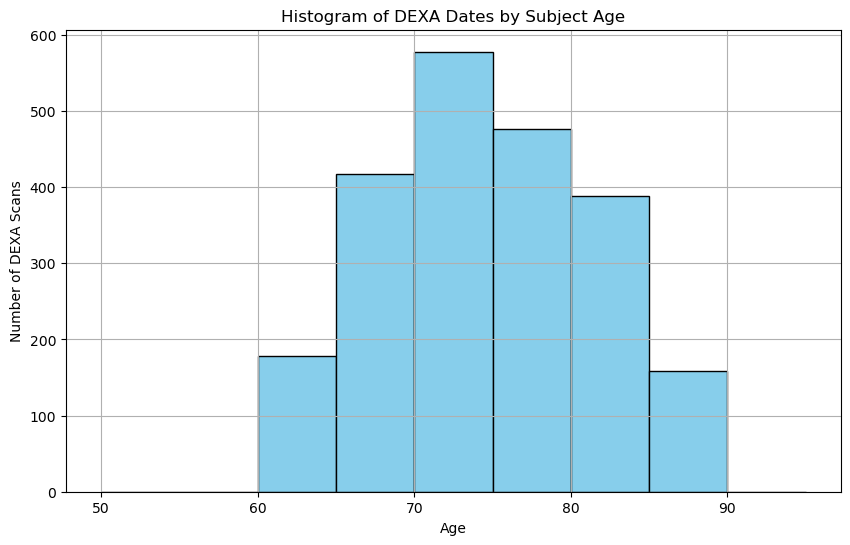

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the Excel file
file_path = 'Copy of WM_SAT_Emp_Population_Output_UIW_20221003 (003).xlsx'

# Load all sheets into a dictionary of DataFrames
excel_data = pd.read_excel(file_path, sheet_name=None)

# Load DEXA and Diabetic Population data
dexa_pop_df = excel_data['DEXA_pop']
diabetic_pop_df = excel_data['Diabetic_Pop']
target_population_df = excel_data['Target_population']

# Convert DEXA dates to datetime format
dexa_pop_df['DEXA_Date'] = pd.to_datetime(dexa_pop_df['DEXA_Dt'])

# a) Total number of unique subjects with a DEXA date
unique_dexa_subjects = dexa_pop_df['anon_id'].nunique()
print(f"Total number of unique subjects with a DEXA date: {unique_dexa_subjects}")

# b) Cross-referencing DEXA subjects with Diabetic Population
dexa_diabetic_intersection = pd.merge(dexa_pop_df[['anon_id']], diabetic_pop_df[['anon_id']], on='anon_id', how='inner')
dexa_in_diabetic = dexa_diabetic_intersection['anon_id'].nunique()
print(f"Number of DEXA subjects also listed in Diabetic_Pop: {dexa_in_diabetic} out of {unique_dexa_subjects}")

# c) Insight into DEXA date x age of the subject
# Merge DEXA data with target population for age data
dexa_age_merged = pd.merge(dexa_pop_df, target_population_df[['anon_id', 'member_age']], on='anon_id', how='left')

# Create a histogram of DEXA dates by age
plt.figure(figsize=(10, 6))
plt.hist(dexa_age_merged['member_age'], bins=range(50, 100, 5), color='skyblue', edgecolor='black')
plt.title('Histogram of DEXA Dates by Subject Age')
plt.xlabel('Age')
plt.ylabel('Number of DEXA Scans')
plt.grid(True)
plt.show()

# Exploratory Data Analysis

In [ ]:
import pandas as pd

In [ ]:
file_path = 'Copy of WM_SAT_Emp_Population_Output_UIW_20221003 (003).xlsx'
dfs = pd.read_excel(file_path, sheet_name=None)

In [ ]:
for key in dfs.keys():
    print(key)

Target_population
Diabetic_Pop
Fracture_pop
Smoking_pop
ETOH_pop
Gluc_lab_pop
A1c_lab_pop
Vit_D_Pop
Alk_Phos_pop
testost_pop
calcium_pop
glom_filt_pop
Insulin_pop
Statin_pop
Glucocorticoid_pop
DEXA_pop


## Target Population Age Distribution Analysis

In [ ]:
dfs['Target_population']['member_age'].describe()

count    26510.000000
mean        72.258770
std          7.781948
min         60.000000
25%         66.000000
50%         71.000000
75%         78.000000
max         89.000000
Name: member_age, dtype: float64


The analysis of the `member_age` column from the `Target_population` DataFrame provides the following insights into the age distribution of the members:

- **Count**: The dataset contains `26,510` observations, indicating the total number of members in the target population.

- **Mean**: The average age of the members is approximately `72.26` years, suggesting that the population skews towards an older demographic.

- **Standard Deviation**: With a standard deviation of `7.78` years, the ages show a moderate level of variation from the mean, indicating diversity in the members' ages.

- **Minimum Age**: The youngest member in the population is `60` years old, setting the lower bound of the age range.

- **25th Percentile**: At the first quartile, `25%` of the members are `66` years or younger, marking the younger quarter of the population.

- **Median Age**: The median age is `71` years, indicating that half of the population is younger and the other half is older than this age. The median provides a central point in the age distribution.

- **75th Percentile**: The third quartile shows that `75%` of the population is `78` years or younger, with the remaining `25%` being older, highlighting the age spread.

- **Maximum Age**: The oldest member in the dataset is `89` years old, which is the upper limit of the age range.

This demographic analysis reveals that the target population predominantly consists of elderly individuals, with a broad age range from `60` to `89` years. The data exhibits a moderate spread in ages, with a significant portion of the population in their early seventies.


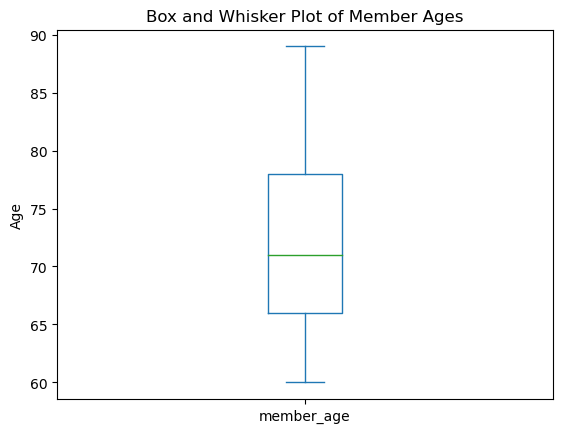

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a series data frame
df = dfs['Target_population']['member_age']

# Create a box and whisker plot
df.plot.box()
plt.title('Box and Whisker Plot of Member Ages')
plt.ylabel('Age')
# Display the plot
plt.show()

## Race

In [ ]:
dfs['Target_population']['member_race'].value_counts()

White                                        7727
Hispanic                                     7423
Other Race                                    829
Unreported/Refused to Report                  791
Declined to Specify                           688
Black or African American                     598
Asian                                         124
African American                               21
American Indian or Alaska Native               17
Native Hawaiian or Other Pacific Islander      12
Declined To Specify                             9
Mexican American Indian                         8
English                                         5
Other Pacific Islander                          3
Black                                           2
Spanish American Indian                         2
European                                        1
American Indian                                 1
white                                           1
White Earth                                     1


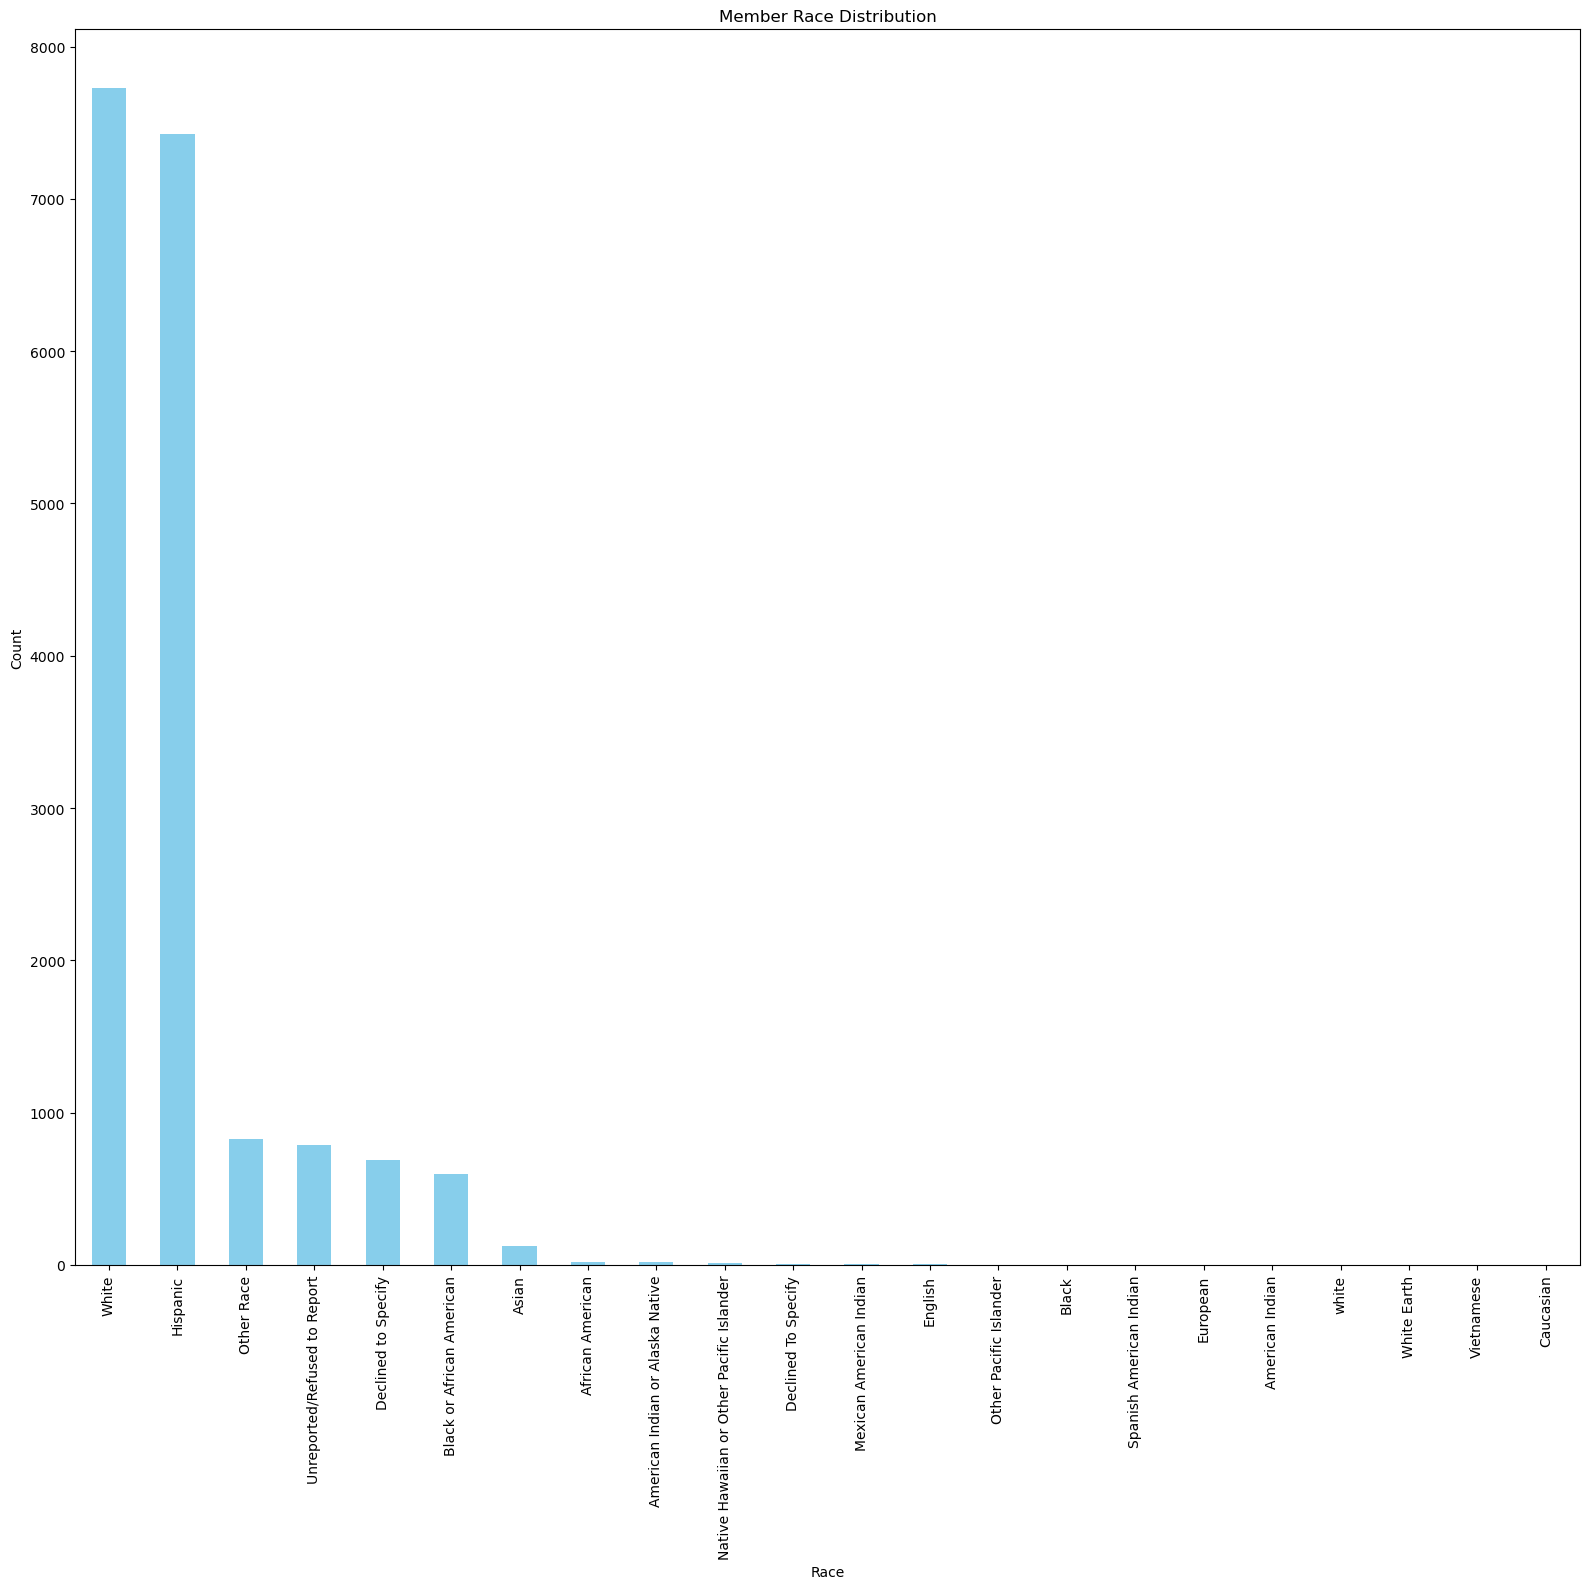

In [ ]:
import matplotlib.pyplot as plt

# Count the occurrences of each unique race category, excluding NaN values
race_counts = dfs['Target_population']['member_race'].value_counts()

# Plotting
plt.figure(figsize=(16, 16))
race_counts.plot(kind='bar', color='skyblue')
plt.title('Member Race Distribution')
plt.xlabel('Race')
plt.ylabel('Count')
# plt.xticks(rotation=45)
plt.tight_layout()


Given the distribution of counts across the member_race categories, we can observe a significant drop in counts beyond certain categories. To enhance the visualization, We might group categories with counts below a certain threshold (e.g., less than 100) into an "Other combined" category to simplify the graph.

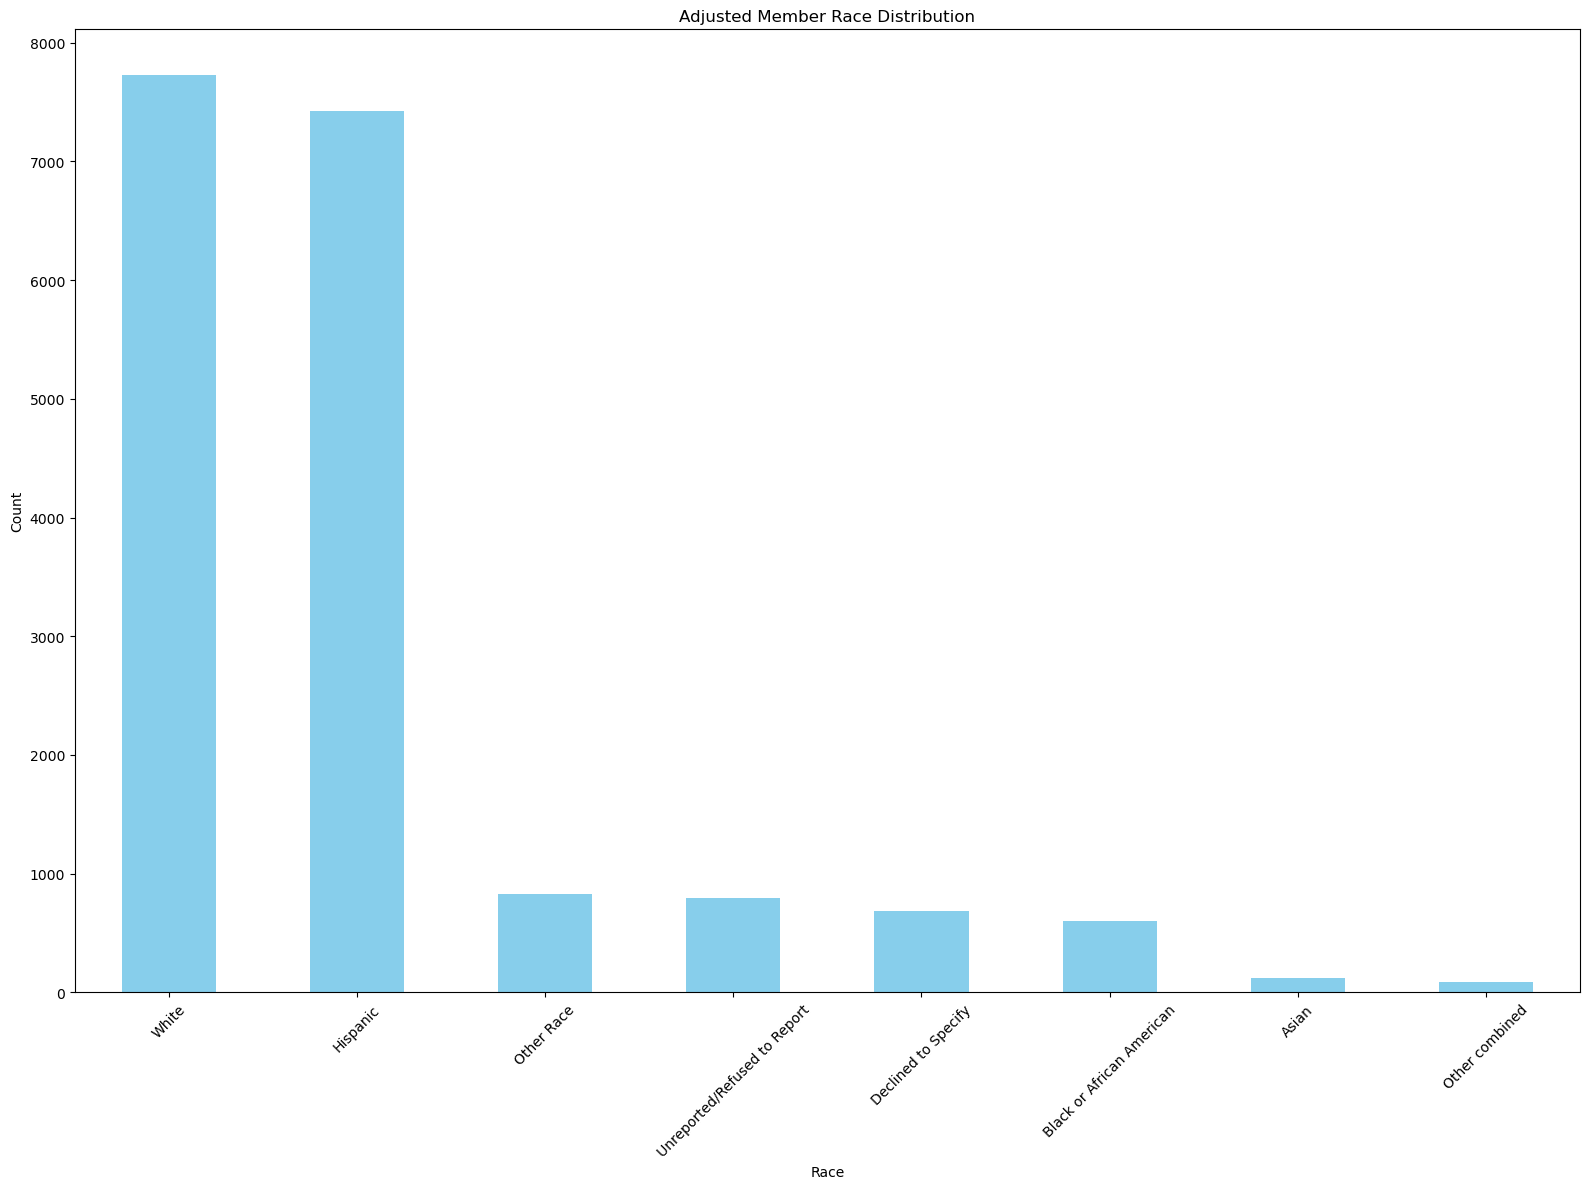

In [ ]:
# Group categories with counts below a threshold into 'Other'
threshold = 100
race_counts_adjusted = race_counts[race_counts >= threshold].copy()
other_count = race_counts[race_counts < threshold].sum()
if other_count > 0:
    race_counts_adjusted['Other combined'] = other_count

# Plotting with adjustments
plt.figure(figsize=(16, 12))
race_counts_adjusted.plot(kind='bar', color='skyblue')
plt.title('Adjusted Member Race Distribution')
plt.xlabel('Race')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()

# Show the adjusted plot
plt.show()


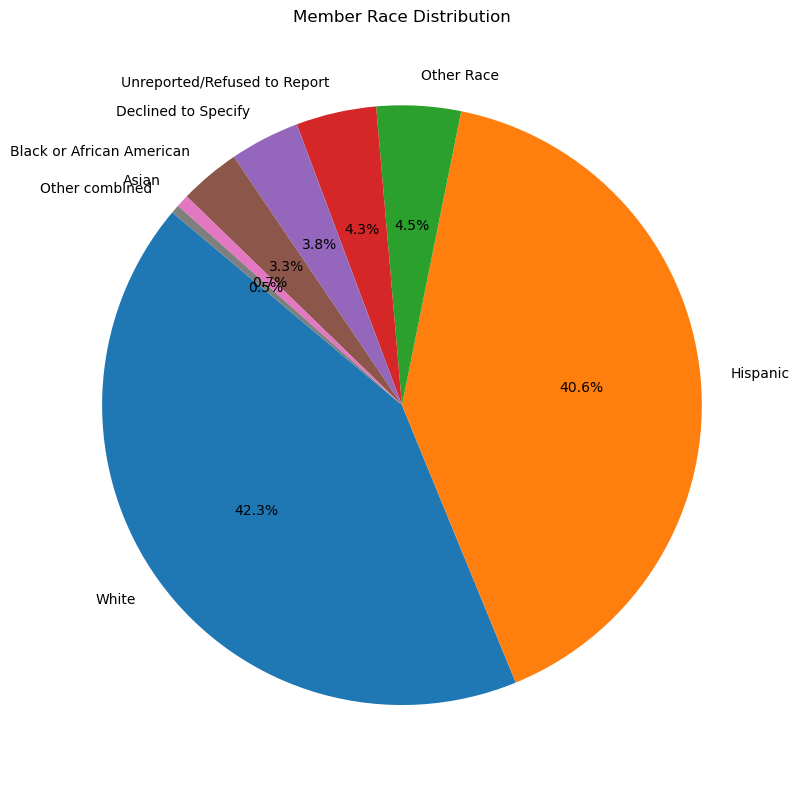

In [ ]:
# Creating a pie chart for the adjusted race counts
plt.figure(figsize=(10, 8))
race_counts_adjusted.plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.ylabel('')  # Hide the y-label as it's not needed for pie charts
plt.title('Member Race Distribution')
plt.tight_layout()

# Show the pie chart
plt.show()


The adjusted bar and pie charts offer a clear view of the racial composition within the `Target_population` dataset, highlighting key insights:

- **Dominant Categories**: "White" and "Hispanic" are the predominant racial groups, showing a population with significant diversity yet clear majorities.

- **Significant Minorities**: Categories like "Other Race," "Unreported/Refused to Report," and "Declined to Specify" indicate a broader diversity, representing individuals who might not fit into traditional racial categories or choose not to disclose their race.

- **Smaller Representations**: "Black or African American" and "Asian" categories, while smaller, are crucial for understanding the full spectrum of the population's racial makeup.

- **Consolidation into "Other combined"**: Grouping less frequent categories under "Other combined" simplifies the data, focusing on major groups while acknowledging the variety of racial identities.


## Member Ethnicity

In [ ]:
# dfs['Target_population']['anon_id']
dfs['Target_population'].keys()

Index(['anon_id', 'member_gender', 'member_age', 'member_race',
       'Member_Ethnicity', 'market'],
      dtype='object')

In [ ]:
member_ethnicity_counts = dfs['Target_population']['Member_Ethnicity'].value_counts()
member_ethnicity_counts

Hispanic or Latino        9580
Not Hispanic or Latino    6832
Refused to Report         1177
Declined to Specify        591
Mexican                     12
Mexican American             5
Latin American               1
Puerto Rican                 1
Central American             1
Name: Member_Ethnicity, dtype: int64

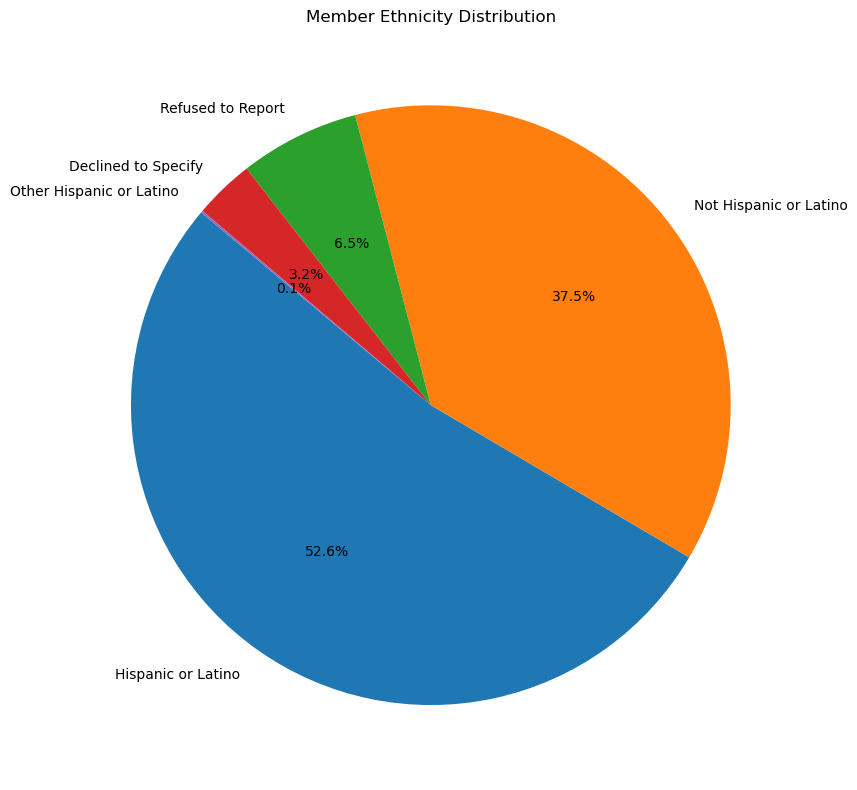

In [ ]:
# Combine the less frequent ethnic groups into an "Other Hispanic or Latino" category
threshold = 100  # Setting a threshold for grouping into 'Other'
member_ethnicity_counts_adjusted = member_ethnicity_counts[member_ethnicity_counts >= threshold].copy()
other_ethnicity_count = member_ethnicity_counts[member_ethnicity_counts < threshold].sum()
if other_ethnicity_count > 0:
    member_ethnicity_counts_adjusted['Other Hispanic or Latino'] = other_ethnicity_count

# Creating a pie chart for the adjusted ethnicity counts
plt.figure(figsize=(10, 8))
member_ethnicity_counts_adjusted.plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.ylabel('')  # Hide the y-label as it's not needed for pie charts
plt.title('Member Ethnicity Distribution')
plt.tight_layout()

# Show the pie chart
plt.show()

Here's the pie chart showing the distribution of the Member_Ethnicity categories within the Target_population dataset, after combining the less frequent ethnic groups into an "Other Hispanic or Latino" category. This visualization provides a clear overview of the proportions each ethnicity holds relative to the total population, highlighting the significant presence of Hispanic or Latino individuals and those who are not Hispanic or Latino, along with a segment for those who refused to report or declined to specify their ethnicity.

## prevalence of diabetes

In [ ]:
# Load the 'Diabetic_Pop' sheet from the Excel file to inspect its structure
# df_diabetic_pop = pd.read_excel(file_path, sheet_name='Diabetic_Pop')

df_diabetic_pop = dfs['Diabetic_Pop']
df_diabetic_pop.head()

,anon_id,earliest_diabetes_dx
0,F7D31775-C766-437C-8F20-5873168374F3,2012-02-16
1,5F430FF2-346F-434A-8A45-04D5795F0EEC,2016-02-05
2,C5984BA6-37B2-4315-A52B-3C28E8DD34CA,2012-02-13
3,262B650A-A9A4-4757-BE2C-F7D1547B6DF8,2012-04-09
4,B82D7718-139E-41AB-90CB-A04DE970E3C7,2012-01-09


In [ ]:
# Calculate the total number of unique individuals in the dataset
total_individuals = df_diabetic_pop['anon_id'].nunique()

# Extract year from 'earliest_diabetes_dx' and calculate the number of diagnoses per year
df_diabetic_pop['diagnosis_year'] = pd.DatetimeIndex(df_diabetic_pop['earliest_diabetes_dx']).year
diagnoses_per_year = df_diabetic_pop['diagnosis_year'].value_counts().sort_index()

print(f'total number of diabetic individuals : {total_individuals} \n')
print('diagnoses per year')
diagnoses_per_year


total number of diabetic individuals : 8682 

diagnoses per year


2012    4263
2013     766
2014     648
2015     622
2016     504
2017     429
2018     457
2019     436
2020     557
Name: diagnosis_year, dtype: int64

The analysis of the Diabetic_Pop dataset reveals:
There are 8,682 unique individuals diagnosed with diabetes, indicating the total diabetic population within the dataset.
The distribution of diabetes diagnoses over the years (from 2012 to 2020) shows varying numbers, with the highest number of diagnoses in 2012 (4,263 cases) and a general decrease in new diagnoses in subsequent years, although there's a slight increase in 2020 compared to 2019.

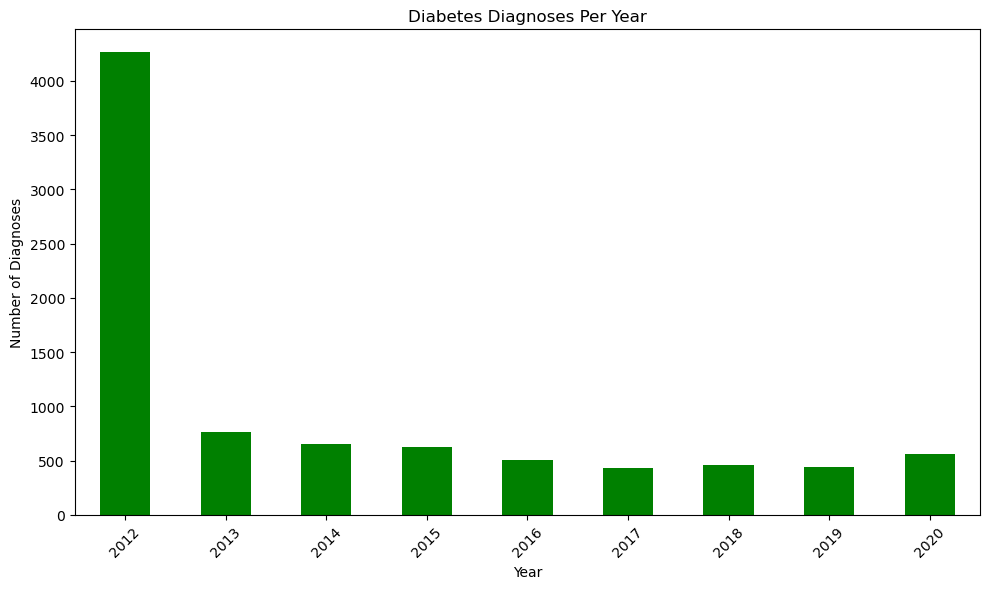

In [ ]:
# Plotting the number of diabetes diagnoses per year
plt.figure(figsize=(10, 6))
diagnoses_per_year.plot(kind='bar', color='green')
plt.title('Diabetes Diagnoses Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Diagnoses')
plt.xticks(rotation=45)
plt.tight_layout()
# Show the plot
plt.show()

In [ ]:
diabetic_prop = dfs['Diabetic_Pop']['anon_id'].nunique()/dfs['Target_population']['anon_id'].nunique()
diabetic_prop

0.3274990569596379

The total population size within the `Target_population` dataset is 26,510 individuals. Of these, 8,682 individuals are diagnosed with diabetes, which constitutes approximately 32.75% of the population. This means that about one-third of the target population is diabetic, highlighting a significant prevalence of diabetes within this group.

In [ ]:
# a = dfs['Target_population']['anon_id'].isin(dfs['Diabetic_Pop']['anon_id'])
# sum(a)

## Duration of diabetics

To analyze the duration of diabetes for individuals in the Diabetic_Pop dataset from a specific date (October 3, 2022), we need to calculate the time elapsed since each individual's earliest diabetes diagnosis until this reference date. This analysis will provide insights into the range of diabetes duration within the population, helping to understand the chronic nature of the condition and the distribution of newly diagnosed versus long-term diabetic individuals.

Let's proceed with this analysis by calculating the duration of diabetes for each individual in the dataset from their earliest diagnosis date until October 3, 2022.

In [ ]:
from datetime import datetime

# Reference date: October 3, 2022
reference_date = datetime(2022, 10, 3)

# Ensure 'earliest_diabetes_dx' is in datetime format
df_diabetic_pop['earliest_diabetes_dx'] = pd.to_datetime(df_diabetic_pop['earliest_diabetes_dx'])

# Recalculate the duration in years from the earliest diagnosis date to the reference date
df_diabetic_pop['duration_years'] = (reference_date - df_diabetic_pop['earliest_diabetes_dx']).dt.days / 365.25

# Summary statistics of the duration of diabetes
duration_stats = df_diabetic_pop['duration_years'].describe()

duration_stats

count    8682.000000
mean        8.289892
std         2.786516
min         1.757700
25%         6.467488
50%         9.672827
75%        10.570842
max        10.754278
Name: duration_years, dtype: float64

The analysis of diabetes duration from the earliest diagnosis date until October 3, 2022, within the `Diabetic_Pop` dataset reveals the following:

- **Count**: There are 8,682 individuals with calculated diabetes duration, matching the number of unique diabetic individuals identified earlier.
- **Mean Duration**: On average, individuals have been living with diabetes for approximately 8.29 years.
- **Standard Deviation**: The standard deviation of 2.79 years indicates variability in the duration individuals have had diabetes.
- **Minimum Duration**: The shortest duration of diabetes in the dataset is about 1.76 years, suggesting some individuals were diagnosed relatively recently before the reference date.
- **25th Percentile (Q1)**: At least 25% of the diabetic individuals have had diabetes for 6.47 years or less, indicating a quarter of the population are relatively recent diagnoses.
- **Median (50th Percentile)**: Half of the diabetic individuals have had diabetes for 9.67 years or less, marking the midpoint of diabetes duration within this population.
- **75th Percentile (Q3)**: About 75% of individuals have had diabetes for 10.57 years or less, suggesting a significant portion of the population were diagnosed over a decade ago.
- **Maximum Duration**: The longest duration of diabetes observed in the dataset is approximately 10.75 years, highlighting individuals who have been managing their condition for a long time.


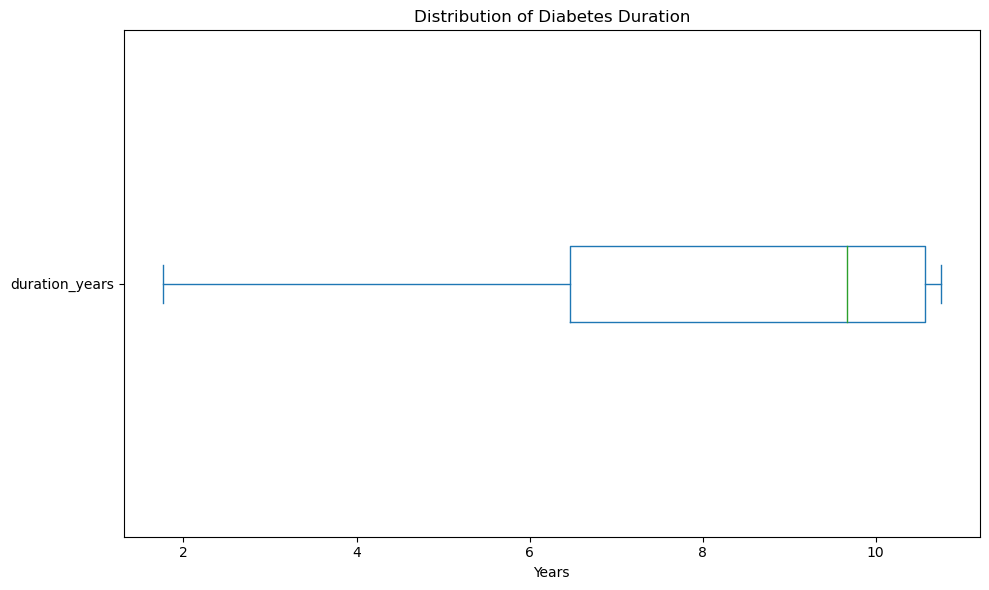

In [ ]:
# Creating a box plot to visualize the distribution of diabetes duration
plt.figure(figsize=(10, 6))
df_diabetic_pop['duration_years'].plot(kind='box', vert=False)
plt.title('Distribution of Diabetes Duration')
plt.xlabel('Years')
plt.tight_layout()

# Show the plot
plt.show()


## prevalence of fractures nondiabetics and diabetics

In [ ]:
file_path = 'Copy of WM_SAT_Emp_Population_Output_UIW_20221003 (003).xlsx'
dfs = pd.read_excel(file_path, sheet_name=None)

df_target_population = dfs['Target_population']
df_diabetic_pop = dfs['Diabetic_Pop']
df_fracture_pop = dfs['Fracture_pop']

# Ensure all anon_id columns are in string format for consistent comparisons
df_target_population['anon_id'] = df_target_population['anon_id'].astype(str)
df_diabetic_pop['anon_id'] = df_diabetic_pop['anon_id'].astype(str)
df_fracture_pop['anon_id'] = df_fracture_pop['anon_id'].astype(str)

# Identify diabetic and nondiabetic individuals
diabetic_ids = set(df_diabetic_pop['anon_id'])
nondiabetic_ids = set(df_target_population['anon_id']) - diabetic_ids

# Identify individuals with fractures
fracture_ids = set(df_fracture_pop['anon_id'])

# Calculate fracture prevalence in diabetic and nondiabetic populations
diabetic_fractures = len(fracture_ids & diabetic_ids)
nondiabetic_fractures = len(fracture_ids & nondiabetic_ids)
diabetic_population_size = len(diabetic_ids)
nondiabetic_population_size = len(nondiabetic_ids)

# Calculate prevalence
prevalence_diabetic = diabetic_fractures / diabetic_population_size
prevalence_nondiabetic = nondiabetic_fractures / nondiabetic_population_size

print(f"total fracture: {len(dfs['Fracture_pop']['anon_id'])}")
diabetic_fractures, nondiabetic_fractures, prevalence_diabetic, prevalence_nondiabetic


total fracture: 1621


(767, 854, 0.08834369960838516, 0.047902176351806144)

The analysis reveals the following about the prevalence of fractures (total fracture = 1621) among diabetic and nondiabetic populations within the `Target_population` dataset:

- **Diabetic Population**:
  - Total individuals with fractures: 767
  - Prevalence of fractures: Approximately 8.83%

- **Nondiabetic Population**:
  - Total individuals with fractures: 854
  - Prevalence of fractures: Approximately 4.79%

This indicates that the prevalence of fractures is higher in the diabetic population (about 8.83%) compared to the nondiabetic population (about 4.79%). This difference suggests a potential association between diabetes and an increased risk of fractures, aligning with existing research that has identified diabetes as a risk factor for bone fractures due to various factors, including changes in bone metabolism, increased risk of falls, and other complications related to diabetes.


# Merge into a single sheet

In [ ]:
import pandas as pd

# Load the Excel file
def load_and_merge_sheets(file_path):
    # Load the Excel file
    xls = pd.ExcelFile(file_path)

    # List all the sheet names in the Excel file
    sheet_names = xls.sheet_names

    # Function to merge all sheets on 'anon_id'
    def merge_sheets(xls, sheet_names):
        # Read the first sheet
        combined_df = pd.read_excel(xls, sheet_name=sheet_names[0])

        # Merge each subsequent sheet into the combined dataframe on 'anon_id'
        for sheet in sheet_names[1:]:
            next_sheet_df = pd.read_excel(xls, sheet_name=sheet)
            combined_df = pd.merge(combined_df, next_sheet_df, on='anon_id', how='outer', suffixes=('', '_dup'))

        # Optional: Resolve any duplicate columns that may have been created during the merge
        # This could be customized based on how you want to handle duplicates
#         for col in combined_df.columns:
#             if '_dup' in col:
#                 original_col = col.replace('_dup', '')
#                 combined_df[original_col] = combined_df[original_col].combine_first(combined_df[col])
#                 combined_df.drop(columns=[col], inplace=True)

        return combined_df

    # Merge all sheets in the Excel file
    combined_data = merge_sheets(xls, sheet_names)
    return combined_data


In [ ]:
# Path to your Excel file
file_path = 'Copy of WM_SAT_Emp_Population_Output_UIW_20221003 (003).xlsx'
combined_data = load_and_merge_sheets(file_path)

# Optional: Save the combined dataframe to a new Excel file
combined_data.to_excel('combined_WM_SAT_Emp_Population_Output_UIW_20221003.xlsx', index=False)

In [ ]:
len(combined_data.keys())

46

In [ ]:
len(combined_data.keys().unique())

36

In [ ]:
combined_data.keys().value_counts().head()

Lab_Result_Name_dup    6
Lab_Result_Date_dup    6
anon_id                1
calcium_val            1
Vit_D_meas             1
dtype: int64

# Analysis

**Research Questions**
1.	Is fracture prevalence increased in diabetic men compared non-diabetic men?
2.	Is this diabetic fracture prevalence higher in Hispanic men compared to non-Hispanic White men?
3.	Among diabetics, are those using insulin more likely to fracture than those not using insulin?
4.	Among diabetics, are there any differences in the relationship’s b/w insulin use and fracture when comparing between Hispanics, Whites, and Blacks?

## Is fracture prevalence increased in diabetic men compared non-diabetic men?

### Code

In [ ]:
df_target_population = dfs['Target_population']
df_diabetic_pop = dfs['Diabetic_Pop']
df_fracture_pop = dfs['Fracture_pop']

# Ensure all anon_id columns are in string format for consistent comparisons
df_target_population['anon_id'] = df_target_population['anon_id'].astype(str)
df_diabetic_pop['anon_id'] = df_diabetic_pop['anon_id'].astype(str)
df_fracture_pop['anon_id'] = df_fracture_pop['anon_id'].astype(str)

# Identify diabetic and nondiabetic individuals
diabetic_ids = set(df_diabetic_pop['anon_id'])
nondiabetic_ids = set(df_target_population['anon_id']) - diabetic_ids

# Identify individuals with fractures
fracture_ids = set(df_fracture_pop['anon_id'])

# Calculate fracture prevalence in diabetic and nondiabetic populations
diabetic_fractures = len(fracture_ids & diabetic_ids)
nondiabetic_fractures = len(fracture_ids & nondiabetic_ids)
diabetic_population_size = len(diabetic_ids)
nondiabetic_population_size = len(nondiabetic_ids)

# Calculate prevalence
prevalence_diabetic = diabetic_fractures / diabetic_population_size
prevalence_nondiabetic = nondiabetic_fractures / nondiabetic_population_size

print(f"total fracture: {len(dfs['Fracture_pop']['anon_id'])}")
diabetic_fractures, nondiabetic_fractures, prevalence_diabetic, prevalence_nondiabetic


total fracture: 1621


(767, 854, 0.08834369960838516, 0.047902176351806144)

### Results

The analysis reveals the following about the prevalence of fractures (total fracture = 1621) among diabetic and nondiabetic populations within the `Target_population` dataset:

- **Diabetic Population**:
  - Total individuals with fractures: 767
  - Prevalence of fractures: Approximately 8.83%

- **Nondiabetic Population**:
  - Total individuals with fractures: 854
  - Prevalence of fractures: Approximately 4.79%

This indicates that the prevalence of fractures is higher (**almost double**) in the diabetic population (about 8.83%) compared to the nondiabetic population (about 4.79%). This difference suggests a potential association between diabetes and an increased risk of fractures, aligning with existing research that has identified diabetes as a risk factor for bone fractures due to various factors, including changes in bone metabolism, increased risk of falls, and other complications related to diabetes.


## Is this diabetic fracture prevalence higher in Hispanic men compared to non-Hispanic White men?

### Code

#### Demographics

In [ ]:
data['Member_Ethnicity'].value_counts()

Hispanic or Latino        9798
Not Hispanic or Latino    7028
Refused to Report         1199
Declined to Specify        597
Mexican                     12
Mexican American             5
Latin American               1
Puerto Rican                 1
Central American             1
Name: Member_Ethnicity, dtype: int64

In [ ]:
data['member_race'].value_counts()

White                                        7946
Hispanic                                     7597
Other Race                                    844
Unreported/Refused to Report                  806
Declined to Specify                           697
Black or African American                     606
Asian                                         127
African American                               21
American Indian or Alaska Native               17
Native Hawaiian or Other Pacific Islander      13
Declined To Specify                             9
Mexican American Indian                         8
English                                         5
Other Pacific Islander                          3
Black                                           2
Spanish American Indian                         2
European                                        1
American Indian                                 1
white                                           1
White Earth                                     1


<AxesSubplot:xlabel='member_age', ylabel='Count'>

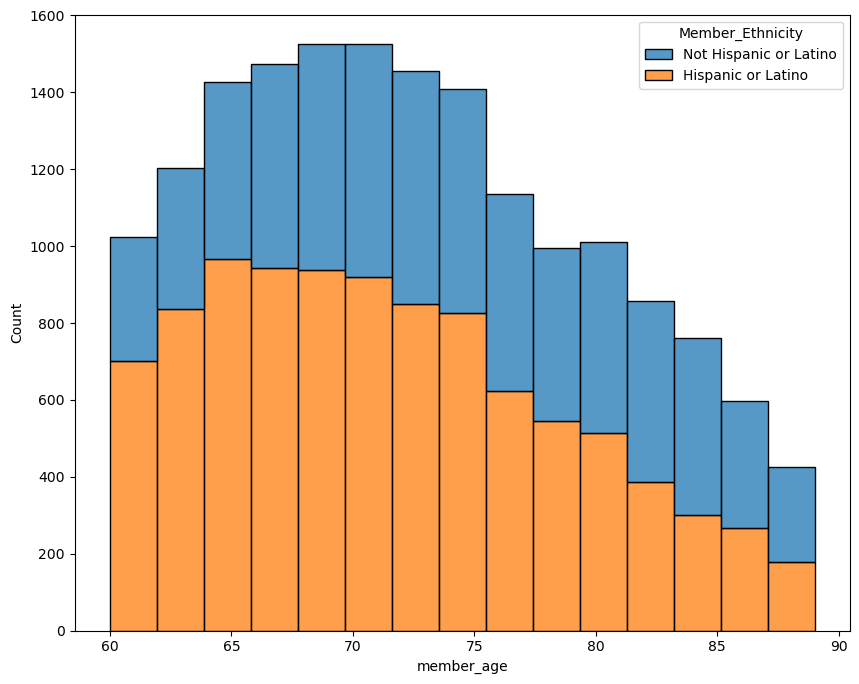

In [ ]:
import seaborn as sns
# Filter data using logical OR -- Ethnicity
data_subset = data[ (data['Member_Ethnicity'] == 'Not Hispanic or Latino') | (data['Member_Ethnicity'] == 'Hispanic or Latino')]
fig, ax = plt.subplots(1,1,figsize=(10,8))
#data_subset = data[data['Member_Ethnicity'] == 'Not Hispanic or Latino' * data['Member_Ethnicity'] == 'Hispanic or Latino']
sns.histplot(data=data_subset, x='member_age',hue='Member_Ethnicity',ax=ax,multiple = 'stack',bins=15)

More older people for Non `Hispanic or Latino` People.

/Users/rafiulislam/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
/Users/rafiulislam/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


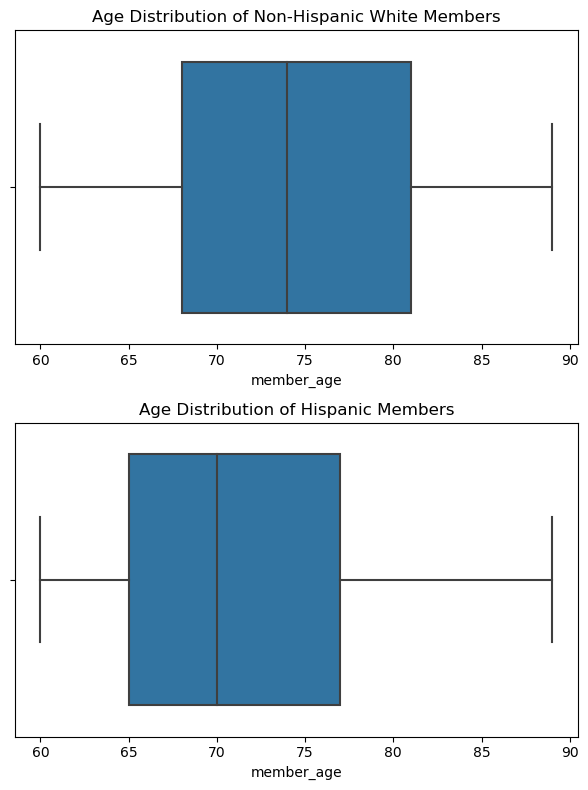

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(2, 1, figsize=(6, 8))

# Boxplot for Non-Hispanic White population
sns.boxplot(filtered_population_NotHispanic_white_df['member_age'], ax=ax[0])
ax[0].set_title('Age Distribution of Non-Hispanic White Members')  # Adding title to the first subplot

# Boxplot for Hispanic population
sns.boxplot(filtered_population_Hispanic_df['member_age'], ax=ax[1])
ax[1].set_title('Age Distribution of Hispanic Members')  # Adding title to the second subplot

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()  # Display the plots


#### Main Code


In [ ]:
# Assuming you have loaded all sheets into dfs from the file
target_population_df = dfs['Target_population']
diabetic_pop_df = dfs['Diabetic_Pop']
fracture_pop_df = dfs['Fracture_pop']

# Ensure anon_id columns are strings for consistent comparisons
target_population_df['anon_id'] = target_population_df['anon_id'].astype(str)
diabetic_pop_df['anon_id'] = diabetic_pop_df['anon_id'].astype(str)
fracture_pop_df['anon_id'] = fracture_pop_df['anon_id'].astype(str)

# Identify diabetic individuals and those with fractures
diabetic_ids = set(diabetic_pop_df['anon_id'])
fracture_ids = set(fracture_pop_df['anon_id'])
diabetic_fractures = diabetic_ids & fracture_ids
num_diabetic_fractures = len(diabetic_fractures)

print(f"Number of individuals identified in both Diabetic and Fracture populations: {num_diabetic_fractures}")

###

# Filter for Hispanic and non-Hispanic White men
filtered_population_NotHispanic_white_df = target_population_df[
  (target_population_df['Member_Ethnicity'].isin(['Not Hispanic or Latino'])) &
  (target_population_df['member_race'] == 'White') &
  (target_population_df['member_gender'] == 'M')
]

# Filter for Hispanic population
filtered_population_Hispanic_df = target_population_df[target_population_df['Member_Ethnicity'].isin(['Hispanic or Latino'])]

NotHispanic_white_ids = set(filtered_population_NotHispanic_white_df['anon_id'])
Hispanic_ids = set(filtered_population_Hispanic_df['anon_id'])
print(f"\nTotal number of Non-Hispanic White men in target population: {len(NotHispanic_white_ids)}")
print(f"Total number of Hispanic individuals in target population: {len(Hispanic_ids)}")

fracture_in_NotHispanic_white_ids = fracture_ids & NotHispanic_white_ids
fracture_prevalence_NotHispanic_white = len(fracture_in_NotHispanic_white_ids) / len(NotHispanic_white_ids)
print(f"\nPrevalence of fractures in Non-Hispanic White men: {fracture_prevalence_NotHispanic_white:.2%}")

fracture_in_Hispanic_ids = fracture_ids & Hispanic_ids
fracture_prevalence_Hispanic = len(fracture_in_Hispanic_ids) / len(Hispanic_ids)
print(f"Prevalence of fractures in Hispanic population: {fracture_prevalence_Hispanic:.2%}")


Number of individuals identified in both Diabetic and Fracture populations: 767

Total number of Non-Hispanic White men in target population: 5582
Total number of Hispanic individuals in target population: 9580

Prevalence of fractures in Non-Hispanic White men: 9.58%
Prevalence of fractures in Hispanic population: 6.85%


### Results

Number of individuals identified in both Diabetic and Fracture populations: 767

Total number of Non-Hispanic White men in target population: 5582

Total number of Hispanic individuals in target population: 9580

Prevalence of fractures in Non-Hispanic White men: 9.58%

Prevalence of fractures in Hispanic population: 6.85%

## Among diabetics, are those using insulin more likely to fracture than those not using insulin?

### Code

In [ ]:
file_path = 'Copy of WM_SAT_Emp_Population_Output_UIW_20221003 (003).xlsx'
# Load necessary data
insulin_df = pd.read_excel(file_path, sheet_name='Insulin_pop')
diabetic_pop_df = pd.read_excel(file_path, sheet_name='Diabetic_Pop')
fracture_pop_df = pd.read_excel(file_path, sheet_name='Fracture_pop')

# Convert anon_id to string to ensure consistent comparisons
insulin_df['anon_id'] = insulin_df['anon_id'].astype(str)
diabetic_pop_df['anon_id'] = diabetic_pop_df['anon_id'].astype(str)
fracture_pop_df['anon_id'] = fracture_pop_df['anon_id'].astype(str)

# Identify all diabetic individuals
all_diabetic_ids = set(diabetic_pop_df['anon_id'])

# Identify individuals with fractures
fracture_ids = set(fracture_pop_df['anon_id'])

# Identify diabetics on insulin and not on insulin
diabetics_on_insulin_ids = set(insulin_df[insulin_df['on_insulins'] == 'yes']['anon_id'])
diabetics_not_on_insulin_ids = all_diabetic_ids - diabetics_on_insulin_ids

# Calculate the intersection of diabetics on insulin and fracture ids
fractures_on_insulin = len(fracture_ids & diabetics_on_insulin_ids)
fractures_not_on_insulin = len(fracture_ids & diabetics_not_on_insulin_ids)

# Calculate total populations
total_diabetics_on_insulin = len(diabetics_on_insulin_ids)
total_diabetics_not_on_insulin = len(diabetics_not_on_insulin_ids)

# Calculate fracture prevalence
prevalence_fractures_on_insulin = fractures_on_insulin / total_diabetics_on_insulin
prevalence_fractures_not_on_insulin = fractures_not_on_insulin / total_diabetics_not_on_insulin

print(f"Fractures among diabetics on insulin: {fractures_on_insulin}, Prevalence: {prevalence_fractures_on_insulin:.2%}")
print(f"Fractures among diabetics not on insulin: {fractures_not_on_insulin}, Prevalence: {prevalence_fractures_not_on_insulin:.2%}")


Fractures among diabetics on insulin: 199, Prevalence: 6.80%
Fractures among diabetics not on insulin: 654, Prevalence: 8.72%


### Results

The results indicate the following about the prevalence of fractures among diabetic individuals, based on their insulin use:

- Diabetics on Insulin: 199 individuals who use insulin have experienced fractures, which represents a prevalence of 6.80%.

- Diabetics Not on Insulin: 654 individuals who do not use insulin have experienced fractures, with a higher prevalence of 8.72%.

These results suggest that diabetic individuals who do not use insulin have a higher rate of fractures compared to those who do use insulin.

## Among diabetics, are there any differences in the relationship’s b/w insulin use and fracture when comparing between Hispanics, Whites, and Blacks?

### Code

In [ ]:
# Assuming you have loaded all sheets into dfs from the file
target_population_df = dfs['Target_population']
# target_population_df = dfs['Diabetic_Pop']
insulin_pop_df = dfs['Insulin_pop']
fracture_pop_df = dfs['Fracture_pop']

# Ensure all anon_id columns are in string format for consistent comparisons
target_population_df['anon_id'] = target_population_df['anon_id'].astype(str)
insulin_pop_df['anon_id'] = insulin_pop_df['anon_id'].astype(str)
fracture_pop_df['anon_id'] = fracture_pop_df['anon_id'].astype(str)
# Filter for Hispanics, Whites, and Blacks and African American
filtered_population = target_population_df[target_population_df['member_race'].isin(['Hispanic', 'White', 'Black or African American'])]
# Map insulin and fracture status
filtered_population['on_insulin'] = filtered_population['anon_id'].isin(insulin_pop_df['anon_id'])
filtered_population['has_fracture'] = filtered_population['anon_id'].isin(fracture_pop_df['anon_id'])
# Group by race and insulin status, then calculate the mean fracture rate
analysis_results = filtered_population.groupby(['member_race', 'on_insulin'])['has_fracture'].mean().unstack()
print(analysis_results)

on_insulin                    False      True
member_race                                  
Black or African American  0.045455  0.062500
Hispanic                   0.074253  0.082517
White                      0.084741  0.051570


/var/folders/h7/2fbbhbp109914gfv3m0_z89w0000gn/T/ipykernel_90707/3034836165.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_population['on_insulin'] = filtered_population['anon_id'].isin(insulin_pop_df['anon_id'])
/var/folders/h7/2fbbhbp109914gfv3m0_z89w0000gn/T/ipykernel_90707/3034836165.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_population['has_fracture'] = filtered_population['anon_id'].isin(fracture_pop_df['anon_id'])


### Results

**Analysis of Fracture Prevalence Among Diabetics by Race and Insulin Use**

The provided analysis reveals distinct patterns of fracture prevalence among diabetics across different racial groups, differentiated by insulin use:

**Fracture Prevalence Results**

- **Black or African American:**
  - **Not on Insulin:** 4.55%
  - **On Insulin:** 6.25%
  
  Among Black or African American diabetics, individuals on insulin show a higher fracture prevalence compared to those not on insulin.

- **Hispanic:**
  - **Not on Insulin:** 7.43%
  - **On Insulin:** 8.25%
  
  For Hispanic diabetics, those on insulin also exhibit a higher fracture prevalence than their counterparts not on insulin.

- **White:**
  - **Not on Insulin:** 8.47%
  - **On Insulin:** 5.16%
  
In contrast to the other racial groups, White diabetics who are not on insulin show a higher prevalence of fractures compared to those who are on insulin. This trend could likely be attributed to a **higher proportion of older individuals** within this demographic group.